In [ ]:
import sys
sys.path.append("../")

from collections import deque

import gymnasium as gym
import numpy as np
from tqdm.auto import tqdm
import torch

import gin

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
import matplotlib.cm as cm

from minigrid_basics.envs import mon_minigrid
from minigrid_basics.envs.mon_minigrid import MonMiniGridEnv
from minigrid.wrappers import RGBImgObsWrapper
from minigrid_basics.custom_wrappers.mdp_wrapper import MDPWrapper, solve_mdp
from minigrid_basics.custom_wrappers.coloring_wrapper import ColoringWrapper

from metamotivo.normalizers import IdentityNormalizerConfig
from metamotivo.agents.fb.agent import FBAgent, FBAgentConfig, FBModelConfig, FBAgentTrainConfig
from metamotivo.agents.fb.model import FBModelArchiConfig
from metamotivo.nn_models import ForwardArchiConfig, BackwardArchiConfig

from metamotivo.buffers.transition import DictBuffer

/home/jovyan/bobrin/td_jepa/.venv/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


/home/jovyan/bobrin/td_jepa/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment MiniGrid-ClassicFourRooms-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


(np.float64(-0.5), np.float64(415.5), np.float64(415.5), np.float64(-0.5))

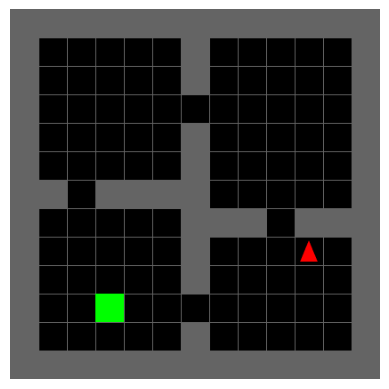

In [3]:
class OneHotWrapper(gym.ObservationWrapper):
    """Converts discrete state indices to one-hot vectors."""
    def __init__(self, env):
        super().__init__(env)
        self.num_states = env.num_states
        self.observation_space = gym.spaces.Box(0, 1, (self.num_states,))
        self.num_actions = env.A
        
        # PROXY these attributes from the wrapped MDPWrapper so they are accessible
        self.width = getattr(env, 'width', None)
        self.A = getattr(env, 'A', None)
        self.height = getattr(env, 'height', None)
        self.num_grid_states = getattr(env, 'num_grid_states', None)
        self.gamma = getattr(env, 'gamma', None)
        self.state_to_pos = getattr(env, 'state_to_pos', None)
        self.rewards = getattr(env, 'rewards', None)
        self.transition_probs = getattr(env, 'transition_probs', None)
        self.pos_to_state = getattr(env, 'pos_to_state', None)
        self.absorbing_state = getattr(env, 'absorbing_state', None)
        
    def observation(self, obs):
        oh = np.zeros(self.num_states, dtype=np.float32)
        if obs['state'] >= 0: oh[obs['state']] = 1.0
        return oh
        
ENV_PATH = "../minigrid_basics/envs/classic_fourrooms.gin"
TILE_SIZE = 32

gin.clear_config()
gin.parse_config_file(ENV_PATH)
env_id = mon_minigrid.register_environment()
env = gym.make(env_id, episodic=True, highlight=False,
            goal_pos=None, agent_pos=None, stochasticity=0.0)
env.reset(seed=0)
env = RGBImgObsWrapper(env, tile_size=TILE_SIZE)
env = MDPWrapper(env, get_rgb=True, gamma=0.95)

obs, info = env.reset()
plt.imshow(obs['image'])
env = OneHotWrapper(env) 
plt.axis('off')

In [4]:
archi_cfg = FBModelArchiConfig(
    L_dim=0,
    z_dim=50,
    norm_z=True,
    f=ForwardArchiConfig(
        hidden_dim=128,
        hidden_layers=3,
        num_parallel=2
    ),
    b=BackwardArchiConfig(
        hidden_dim=128,
        hidden_layers=3,
        norm=True
    ),
)
fb_cfg = FBAgentConfig(
    compile=True,
    discrete=True,
    model=FBModelConfig(
        obs_normalizer=IdentityNormalizerConfig(),
        inference_batch_size=1, # goal conditioned for discrete
        archi=archi_cfg,
        actor_encode_obs=False
    ),
    train=FBAgentTrainConfig(
        batch_size=1024,
        discount=0.99,
        ortho_coef=0.0,
        discrete_temperature = 5.0
    ),
)
agent = FBAgent(obs_space=env.observation_space, action_dim=env.action_space.n, cfg=fb_cfg)

compile True
compiling with mode 'reduce-overhead'
cudagraphs False


In [55]:
def collect_data(env, capacity=100_000, p_optimal=0.4, device="cpu", exact_coverage=False, max_path_length=25):
    """
    Collect offline data into DictBuffer with episodic goals and sequence limits.
    Each trajectory in the buffer is strictly max_path_length long.
    Policy (optimal vs random) is chosen once per trajectory.
    """
    
    def get_attr(e, name):
        """Helper to find attributes in a wrapper chain."""
        if hasattr(e, name): return getattr(e, name)
        curr = e
        while hasattr(curr, 'env'):
            curr = curr.env
            if hasattr(curr, name): return getattr(curr, name)
        return None

    # Get MDP properties
    num_states = get_attr(env, 'num_states')
    num_grid_states = get_attr(env, 'num_grid_states')
    transition_probs = get_attr(env, 'transition_probs')
    absorbing_state = get_attr(env, 'absorbing_state')
    num_actions = env.action_space.n
    pos_to_state = get_attr(env, 'pos_to_state')
    
    # Store goal-specific policies to speed up collection
    policy_cache = {}

    # 1. Determine Observation Shape
    obs_sample, _ = env.reset()
    obs_dim = obs_sample.shape[0] if isinstance(obs_sample, np.ndarray) else 1

    if exact_coverage:
        if transition_probs is None:
            raise ValueError("exact_coverage=True requires 'transition_probs' attribute in env chain.")
        print(f"Collecting exact coverage: {num_states} states x {num_actions} actions...")
        s_indices = np.repeat(np.arange(num_states), num_actions)
        a_indices = np.tile(np.arange(num_actions), num_states)
        obs_t = torch.zeros((len(s_indices), obs_dim), dtype=torch.float32, device=device)
        next_obs_t = torch.zeros((len(s_indices), obs_dim), dtype=torch.float32, device=device)
        act_t = torch.tensor(a_indices, dtype=torch.long, device=device).view(-1, 1)
        next_s_list = []
        for i, (s, a) in enumerate(zip(s_indices, a_indices)):
            if obs_dim > 1:
                obs_t[i, s] = 1.0
            else:
                obs_t[i, 0] = float(s)
            probs = transition_probs[s, a]
            ns = np.random.choice(len(probs), p=probs)
            next_s_list.append(ns)
            if obs_dim > 1:
                if ns < num_states: next_obs_t[i, ns] = 1.0
            else:
                next_obs_t[i, 0] = float(ns)
        done_t = (torch.tensor(next_s_list, device=device) == absorbing_state).to(torch.bool).view(-1, 1)
    else:
        # Standard episodic trajectories
        obs_t      = torch.empty((capacity, obs_dim), dtype=torch.float32, device=device)
        next_obs_t = torch.empty((capacity, obs_dim), dtype=torch.float32, device=device)
        act_t      = torch.empty((capacity, 1), dtype=torch.long,    device=device)
        done_t     = torch.empty((capacity, 1), dtype=torch.bool,    device=device)

        env_done = True
        current_path_len = 0
        traj_is_optimal = False
        current_goal_idx = None
        pi_optimal = None
        obs_raw, _ = env.reset()

        print(f"Collecting trajectory data (max_len={max_path_length})...")
        
        for step in tqdm(range(capacity)):
            if current_path_len == 0:
                # Start of a new trajectory: pick a goal and decide if this trajectory is optimal
                traj_is_optimal = (np.random.random() < p_optimal)
                current_goal_idx = np.random.randint(0, num_grid_states)
                
                if p_optimal > 0:
                    if current_goal_idx not in policy_cache:
                        curr = env
                        while hasattr(curr, 'env') and not hasattr(curr, 'rewards'):
                            curr = curr.env
                        
                        if hasattr(curr, 'rewards'):
                            old_R = curr.rewards.copy()
                            R_tmp = np.zeros_like(old_R)
                            R_tmp[current_goal_idx, :] = 1.0 
                            curr.rewards = R_tmp
                            mdp_res = mdp_wrapper.solve_mdp(env)
                            policy_cache[current_goal_idx] = np.argmax(mdp_res['policy'], axis=1)
                            curr.rewards = old_R
                        else:
                            policy_cache[current_goal_idx] = None
                    pi_optimal = policy_cache[current_goal_idx]
                else:
                    pi_optimal = None

            if env_done:
                obs_raw, _ = env.reset()
                env_done = False

            # Get current state index
            unwrapped = env.unwrapped
            s_idx = pos_to_state.get(unwrapped.agent_pos[0] + unwrapped.agent_pos[1] * unwrapped.width, -1)

            # Use the policy assigned to THIS trajectory
            if traj_is_optimal and pi_optimal is not None:
                action = pi_optimal[s_idx]
            else:
                action = env.action_space.sample()

            next_obs_raw, reward, terminated, truncated, info = env.step(int(action))
            current_path_len += 1
            
            # Check if environment reached goal or terminal state
            ns_idx = pos_to_state.get(unwrapped.agent_pos[0] + unwrapped.agent_pos[1] * unwrapped.width, -1)
            at_goal = (ns_idx == current_goal_idx)
            env_done = bool(terminated or truncated or at_goal)

            # Trajectory termination logic for the buffer (fixed length)
            is_last_step = (current_path_len >= max_path_length)

            obs_t[step].copy_(torch.as_tensor(obs_raw, dtype=torch.float32, device=device))
            next_obs_t[step].copy_(torch.as_tensor(next_obs_raw, dtype=torch.float32, device=device))
            act_t[step, 0] = int(action)
            done_t[step, 0] = is_last_step

            # Reset trajectory counter if we've filled the current window
            if is_last_step:
                current_path_len = 0
                env_done = True # Start fresh environment state for the next trajectory

            obs_raw = next_obs_raw

    buffer = DictBuffer(capacity=len(obs_t), device=device)
    data_dict = {
        "observation": obs_t, "action": act_t,
        "next": {"observation": next_obs_t, "terminated": done_t}
    }
    buffer.extend(data_dict)
    return {"train": buffer}

# Example call (matches your notebook call)
replay_buffer = collect_data(env, capacity=100_000, max_path_length=15, p_optimal=0.0)

  0%|          | 0/100000 [00:00<?, ?it/s]

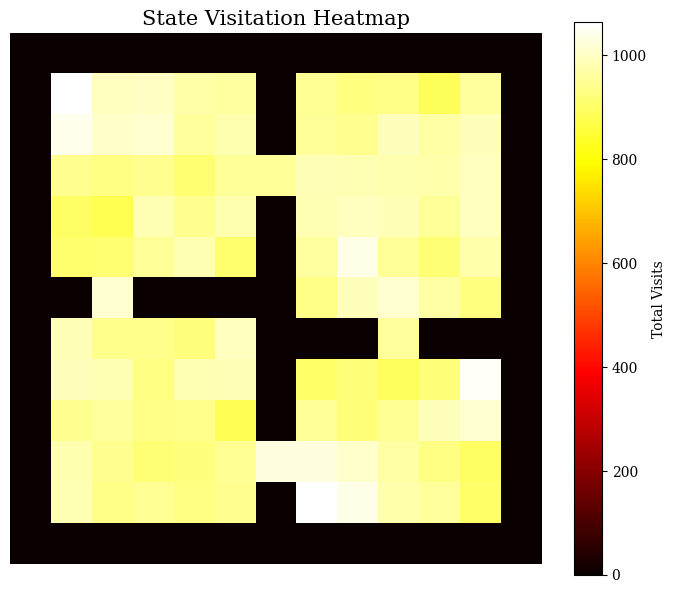

In [56]:
def plot_visitation_heatmap(buffer, env):
    """
    Plots a heatmap showing how many times each grid cell was visited in the buffer.
    """
    # 1. Extract observations from buffer
    obs = buffer.storage["observation"]
    if hasattr(obs, 'cpu'):
        obs = obs.cpu().numpy()
        
    # 2. Convert observations to state indices
    if obs.shape[1] > 1:
        # Assume one-hot encoding (Standard for the notebook)
        state_indices = np.argmax(obs, axis=1)
    else:
        # Assume direct state indices
        state_indices = obs.reshape(-1).astype(int)
        
    # 3. Aggregrate counts onto the grid
    # env.height and env.width are available from MDPWrapper
    heatmap = np.zeros((env.height, env.width))
    
    # Map each state index to its grid (x, y) coordinates
    for s_idx in state_indices:
        if s_idx in env.state_to_pos:
            x, y = env.state_to_pos[s_idx]
            heatmap[y, x] += 1
            
    # 4. Visualization
    plt.figure(figsize=(7, 6))
    plt.title("State Visitation Heatmap", fontsize=15)
    
    # Use 'hot' or 'viridis' colormap. Log scaling can help if some states are visited much more than others.
    # heatmap = np.log1p(heatmap) # Uncomment for log-scale if counts are very skewed
    
    im = plt.imshow(heatmap, cmap='hot', interpolation='nearest')
    plt.colorbar(im, label='Total Visits')
    
    # Mask out the border/walls by looking at where the counts are 0
    # (Optional: overlay the environment image if available)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Usage:
# Since collect_data returns a dict {"train": buffer}
plot_visitation_heatmap(replay_buffer["train"], env)

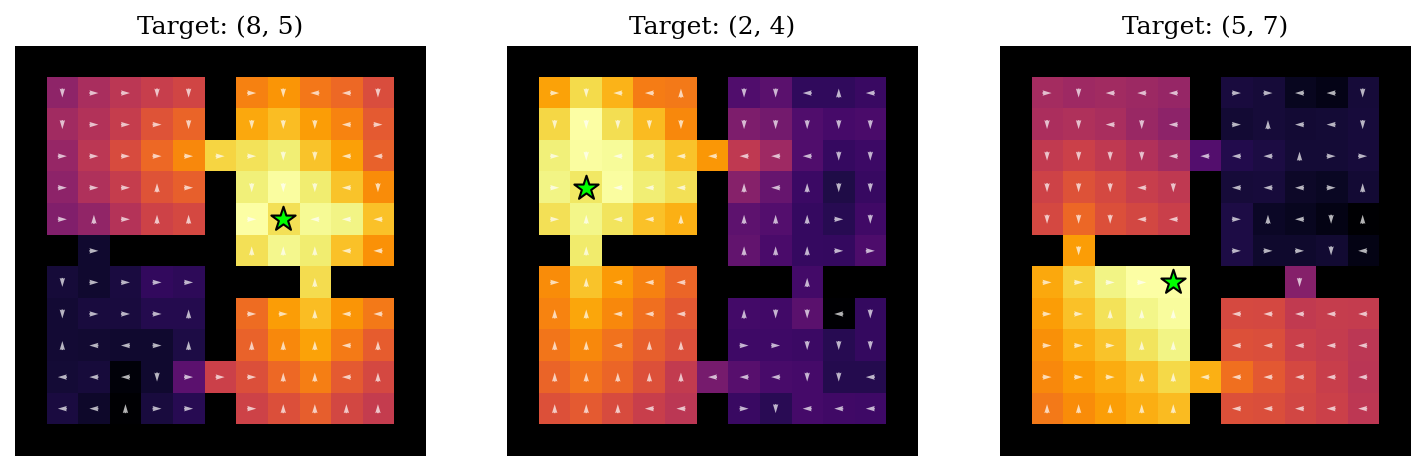

In [61]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


def get_action_deltas_from_env(env):
    """
    Infer (dx, dy) for each discrete action from the env's transition_probs/state_to_pos.

    Returns:
        dx, dy: lists of length num_actions such that action a moves by (dx[a], dy[a])
        in grid coordinates (x to the right, y downward).
    """
    # Prefer attributes proxied by OneHotWrapper -> MDPWrapper -> TabularWrapper
    transition_probs = getattr(env, "transition_probs", None)
    state_to_pos = getattr(env, "state_to_pos", None)
    absorbing_state = getattr(env, "absorbing_state", None)
    num_actions = getattr(env, "num_actions", env.action_space.n)

    # Fallback to standard MiniGrid ordering if we don't have MDP info
    if transition_probs is None or state_to_pos is None:
        # 0:R, 1:D, 2:L, 3:U (MiniGrid directional)
        return [1, 0, -1, 0], [0, 1, 0, -1]

    dx = [0] * num_actions
    dy = [0] * num_actions

    P = transition_probs  # shape (S, A, S)

    for a in range(num_actions):
        found = False

        # Scan over states to find a representative non-trivial transition for this action
        for s_idx, (x, y) in state_to_pos.items():
            if absorbing_state is not None and s_idx == absorbing_state:
                continue

            probs = P[s_idx, a]
            ns_idx = int(probs.argmax())  # most likely next state

            if ns_idx == s_idx:
                # likely wall / stay in place; skip
                continue
            if ns_idx not in state_to_pos:
                continue

            nx, ny = state_to_pos[ns_idx]
            delta_x, delta_y = nx - x, ny - y
            if delta_x == 0 and delta_y == 0:
                continue  # degenerate

            dx[a], dy[a] = delta_x, delta_y
            found = True
            break

        # If we couldn't infer anything, leave dx[a], dy[a] at 0 (no movement)

    return dx, dy

def visualize_fb(env, agent, goal_coords, power_norm=0.5):
    device = agent.device
    width, height = env.width, env.height
    num_states = env.num_states

    # Derive mapping from env
    dx, dy = get_action_deltas_from_env(env)

    plt.rcParams.update({'font.size': 10, 'font.family': 'serif'})
    fig, axes = plt.subplots(1, len(goal_coords), figsize=(4 * len(goal_coords), 4), dpi=150)
    if len(goal_coords) == 1:
        axes = [axes]

    v_grids = []
    policy_data = []

    # 1. Compute Values & Greedy Policy w.r.t FB Q
    for gx, gy in goal_coords:
        goal_state_idx = env.pos_to_state.get(gx + gy * width, -1)
        if goal_state_idx < 0:
            raise ValueError(f"Goal ({gx}, {gy}) is not a valid state.")

        with torch.no_grad():
            # One-hot goal state
            g_obs = torch.zeros((1, num_states), device=device)
            g_obs[0, goal_state_idx] = 1.0
            
            # 1.1 Compute Goal Embedding z
            # backward_map includes _normalize and _bw_encoder
            z = agent._model.backward_map(g_obs) 
            # Ensure z is projected/normalized just like during training
            z = agent._model.project_z(z)

        v_grid = np.full((height, width), np.nan, dtype=np.float32)
        arrows = {'x': [], 'y': [], 'u': [], 'v': []}

        for s_idx, (x, y) in env.state_to_pos.items():
            with torch.no_grad():
                s_obs = torch.zeros((1, num_states), device=device)
                s_obs[0, s_idx] = 1.0

                # 1.2 NORMALIZE AND ENCODE the state (Crucial if L_dim != 0)
                s_obs_norm = agent._model._normalize(s_obs)
                s_enc = agent._model._target_left_encoder(agent._model._fw_encoder(s_obs_norm))

                # 1.3 Target forward_map on encoded state
                # Fs shape: (P, S=1, Z, A)
                Fs = agent._model._target_forward_map(s_enc, z)

                # 1.4 Q-values: dot product <F, z>
                # qs shape: (P, A)
                qs = torch.einsum('psza, sz -> psa', Fs, z).squeeze(1)

                # Pessimistic reduction over ensemble
                _, _, pessimistic_q = agent.get_targets_uncertainty(
                    qs, agent.cfg.train.fb_pessimism_penalty
                )
                
                Q_cpu = pessimistic_q.cpu().numpy()
                best_a = int(np.argmax(Q_cpu))
                v_grid[y, x] = Q_cpu[best_a]

                arrows['x'].append(x)
                arrows['y'].append(y)
                arrows['u'].append(dx[best_a])
                arrows['v'].append(dy[best_a])

        # Optional power normalization for better visibility
        if power_norm is not None:
            v_vis = v_grid.copy()
            mask = ~np.isnan(v_vis) & (v_vis > 0)
            v_vis[mask] = np.power(v_vis[mask], power_norm)
        else:
            v_vis = v_grid

        v_grids.append(v_vis)
        policy_data.append(arrows)

    # 2. Plotting (Same as before)
    for idx, ax in enumerate(axes):
        gx, gy = goal_coords[idx]
        im = ax.imshow(v_grids[idx], cmap='inferno', origin='upper', zorder=1)

        wall_mask = np.zeros((height, width))
        for x in range(width):
            for y in range(height):
                if env.pos_to_state.get(x + y * width, -1) == -1:
                    wall_mask[y, x] = 1
        ax.imshow(np.ma.masked_where(wall_mask == 0, wall_mask), cmap='binary_r', alpha=1.0, origin='upper', zorder=2)

        ax.quiver(policy_data[idx]['x'], policy_data[idx]['y'], policy_data[idx]['u'], policy_data[idx]['v'],
                  color='white', scale=3.5, scale_units='xy', angles='xy', pivot='mid', width=0.006, headwidth=3, alpha=0.7, zorder=3)
        ax.scatter(gx, gy, c='lime', marker='*', s=150, edgecolors='black', zorder=4)
        ax.set_title(f"Target: ({gx}, {gy})")
        ax.axis('off')

    plt.show()
visualize_fb(env, agent, [(8, 5), (2, 4), (5, 7)])


In [58]:
archi_cfg = FBModelArchiConfig(
    L_dim=128,
    z_dim=50,
    norm_z=True,
    f=ForwardArchiConfig(
        hidden_dim=128,
        hidden_layers=3,
        num_parallel=2
    ),
    #left_encoder=BackwardArchiConfig(),
    b=BackwardArchiConfig(
        hidden_dim=128,
        hidden_layers=3,
        norm=True
    ),
)
fb_cfg = FBAgentConfig(
    compile=False,
    discrete=True,
    model=FBModelConfig(
        obs_normalizer=IdentityNormalizerConfig(),
        inference_batch_size=1, # goal conditioned for discrete
        archi=archi_cfg,
        actor_encode_obs=False
    ),
    train=FBAgentTrainConfig(
        discount=0.95,
        ortho_coef=0.2,
        lr_f=3e-4,
        lr_b=3e-4,         
        fb_pessimism_penalty=0.1,
    ),
)
agent = FBAgent(obs_space=env.observation_space, action_dim=env.action_space.n, cfg=fb_cfg)

compile False
cudagraphs False


In [59]:
from rich.pretty import pprint
pprint(agent.cfg)

FBAgentConfig(
│   name='FBAgent',
│   model=FBModelConfig(
│   │   name='FBModel',
│   │   device='cuda',
│   │   archi=FBModelArchiConfig(
│   │   │   name='FBModelArchiConfig',
│   │   │   L_dim=128,
│   │   │   z_dim=50,
│   │   │   norm_z=True,
│   │   │   f=ForwardArchiConfig(
│   │   │   │   name='ForwardArchi',
│   │   │   │   hidden_dim=128,
│   │   │   │   model='simple',
│   │   │   │   hidden_layers=3,
│   │   │   │   embedding_layers=2,
│   │   │   │   num_parallel=2,
│   │   │   │   ensemble_mode='batch'
│   │   │   ),
│   │   │   b=BackwardArchiConfig(name='BackwardArchi', hidden_dim=128, hidden_layers=3, norm=True),
│   │   │   actor=SimpleActorArchiConfig(
│   │   │   │   name='simple',
│   │   │   │   model='simple',
│   │   │   │   hidden_dim=1024,
│   │   │   │   hidden_layers=1,
│   │   │   │   embedding_layers=2
│   │   │   ),
│   │   │   left_encoder=IdentityNNConfig(name='Identity'),
│   │   │   rgb_encoder=IdentityNNConfig(name='Identity'),
│   │   │   augmentator=IdentityNNConfig(name='Identity')
│   │   ),
│   │   obs_normalizer=IdentityNormalizerConfig(name='IdentityNormalizerConfig'),
│   │   inference_batch_size=1,
│   │   seq_length=1,
│   │   actor_std=0.2,
│   │   amp=False,
│   │   actor_encode_obs=False
│   ),
│   train=FBAgentTrainConfig(
│   │   name='FBAgentTrainConfig',
│   │   lr_f=0.0003,
│   │   lr_b=0.0003,
│   │   lr_actor=0.0001,
│   │   weight_decay=0.0,
│   │   clip_grad_norm=0.0,
│   │   f_target_tau=0.01,
│   │   b_target_tau=0.01,
│   │   ortho_coef=0.2,
│   │   train_goal_ratio=0.5,
│   │   fb_pessimism_penalty=0.1,
│   │   actor_pessimism_penalty=0.0,
│   │   stddev_clip=0.3,
│   │   q_loss_coef=0.0,
│   │   batch_size=1024,
│   │   discount=0.95,
│   │   use_mix_rollout=False,
│   │   update_z_every_step=150,
│   │   z_buffer_size=10000,
│   │   bc_coeff=0.0,
│   │   discrete_temperature=10.0
│   ),
│   cudagraphs=False,
│   compile=False,
│   discrete=True
)


Starting FB training for 100000 iterations...


  0%|          | 0/100001 [00:00<?, ?it/s]


--- Visualization at Update 2000 ---


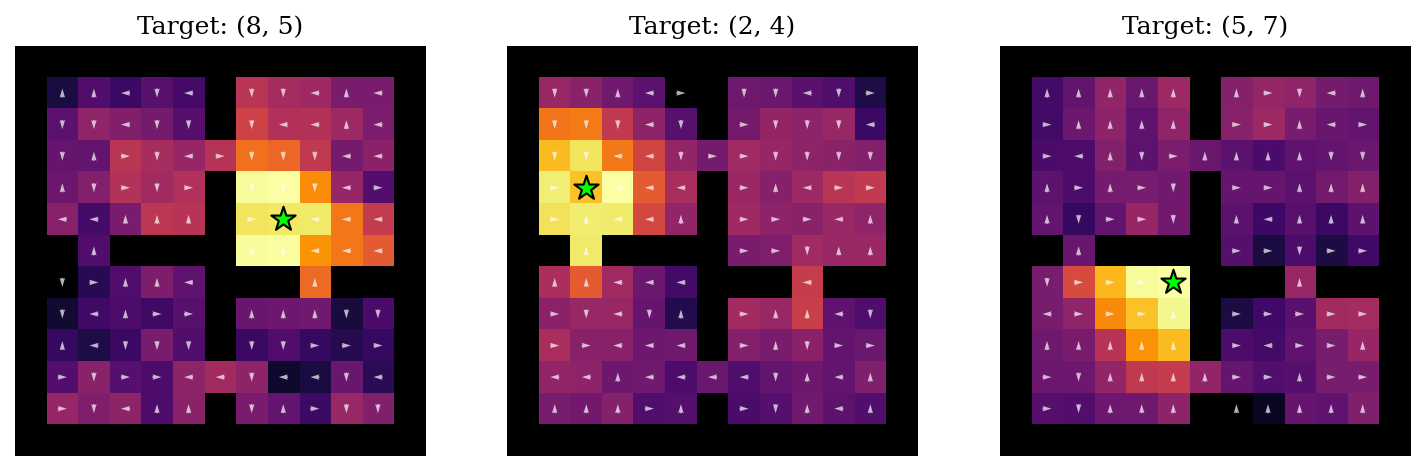


--- Visualization at Update 4000 ---


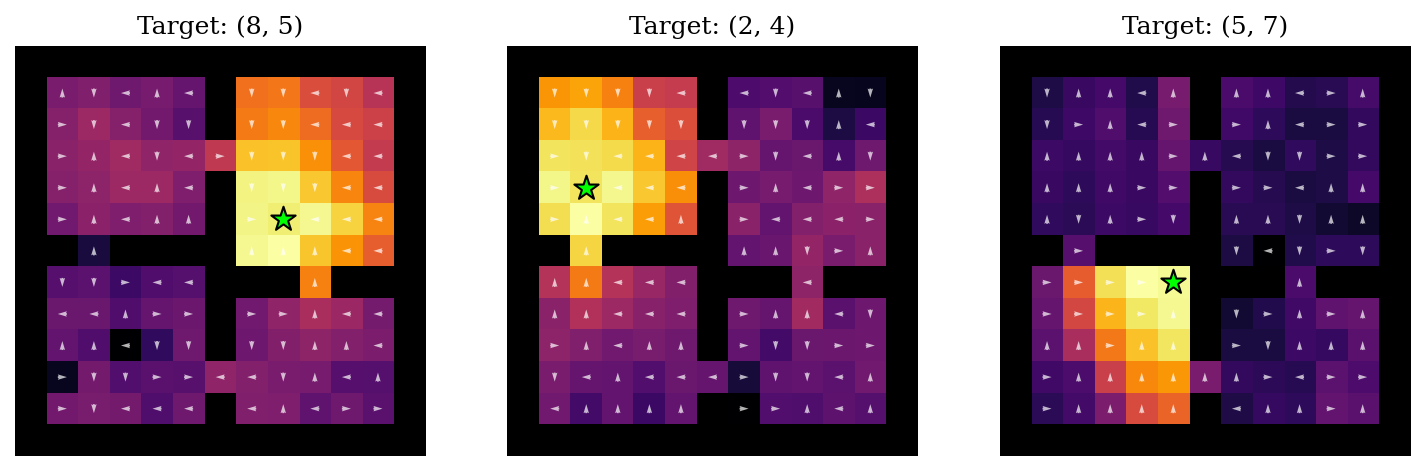


--- Visualization at Update 6000 ---


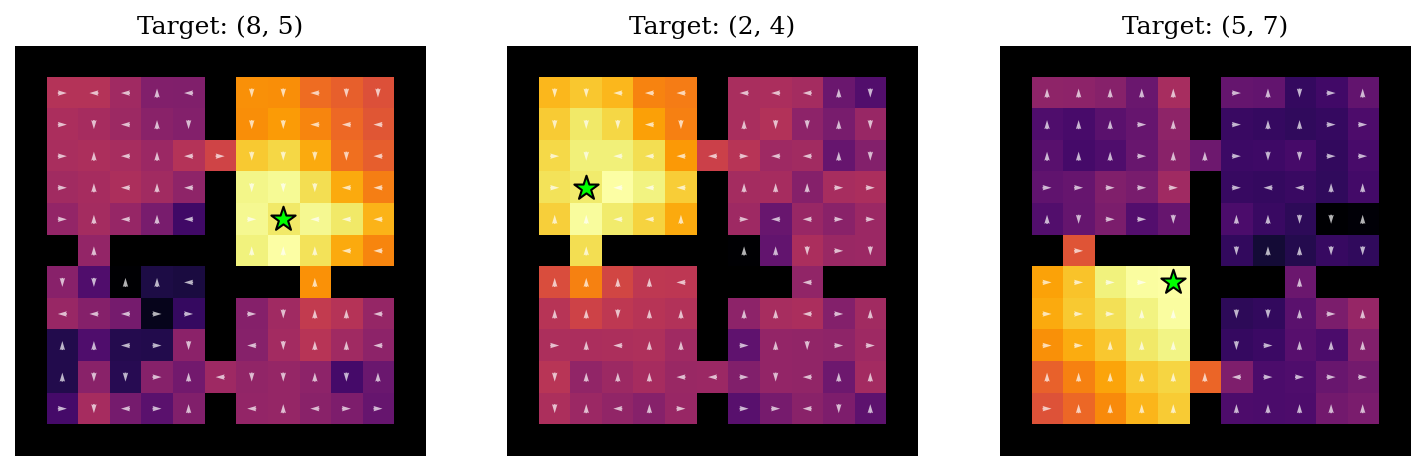


--- Visualization at Update 8000 ---


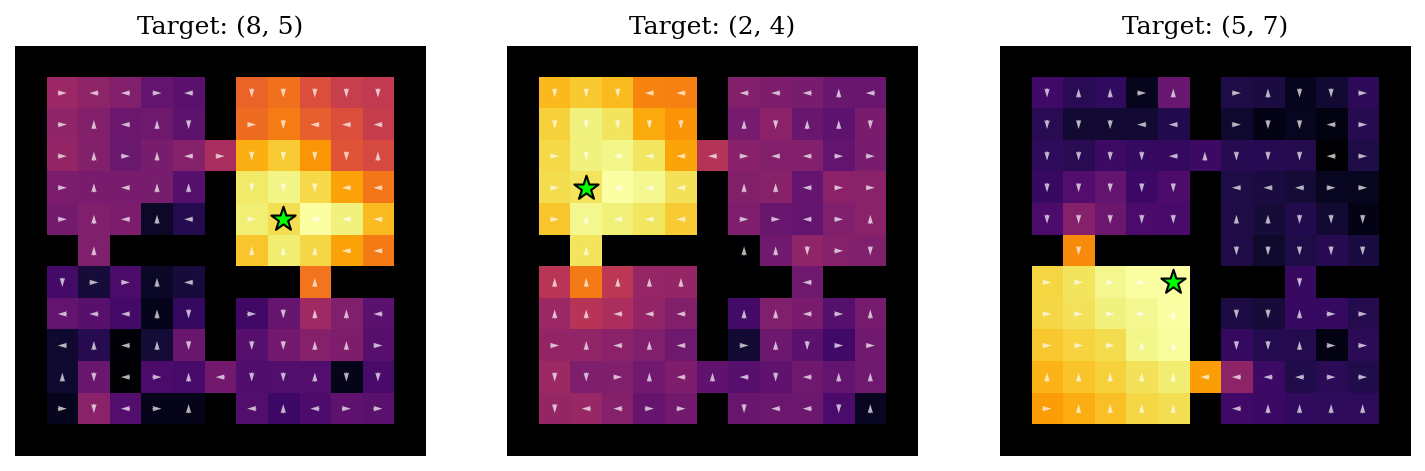


--- Visualization at Update 10000 ---


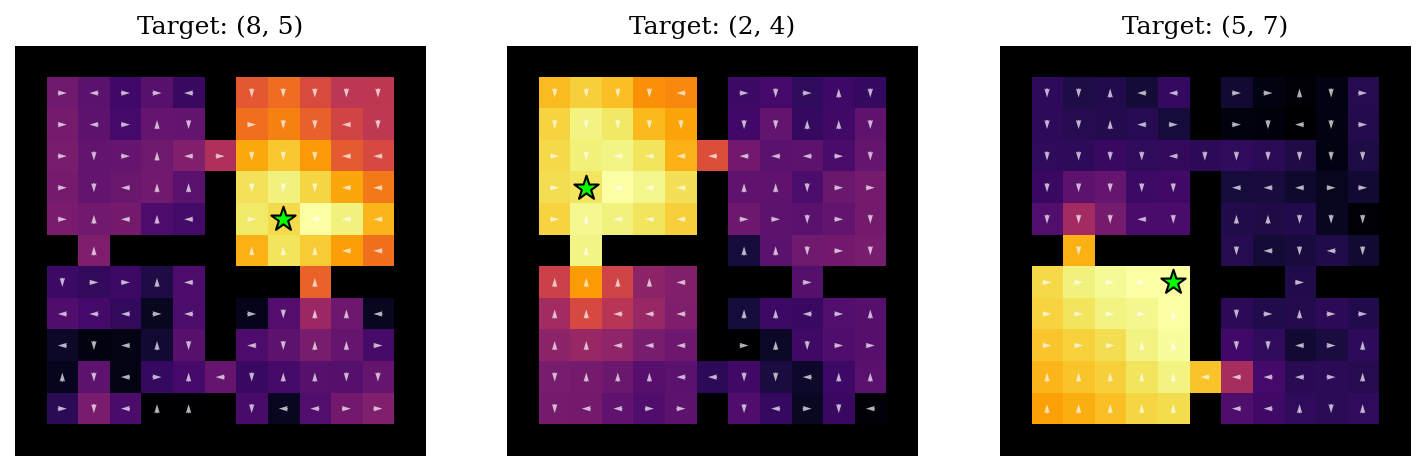


--- Visualization at Update 12000 ---


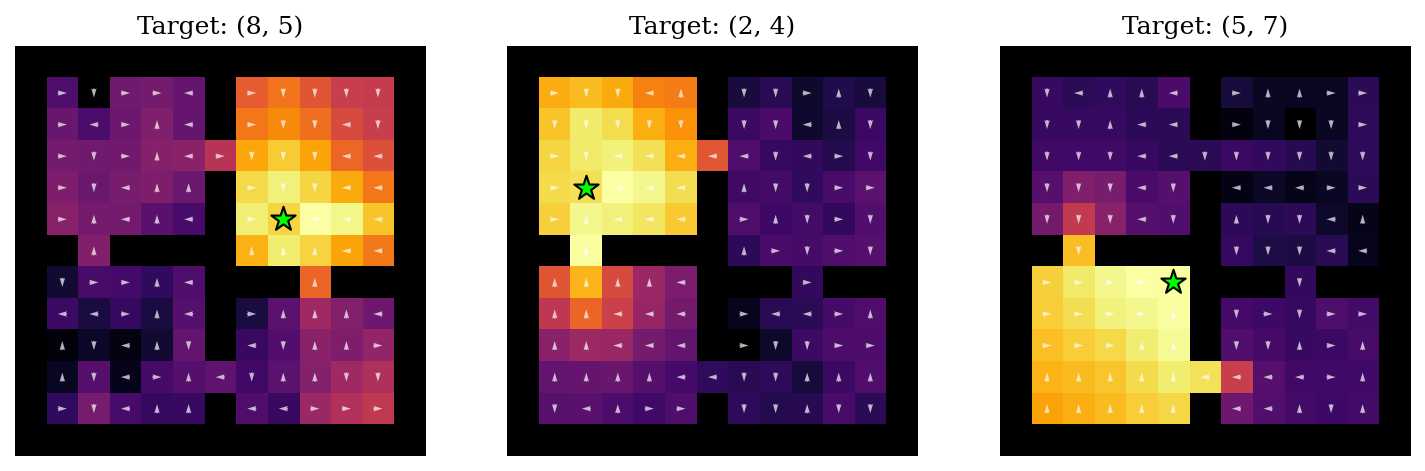


--- Visualization at Update 14000 ---


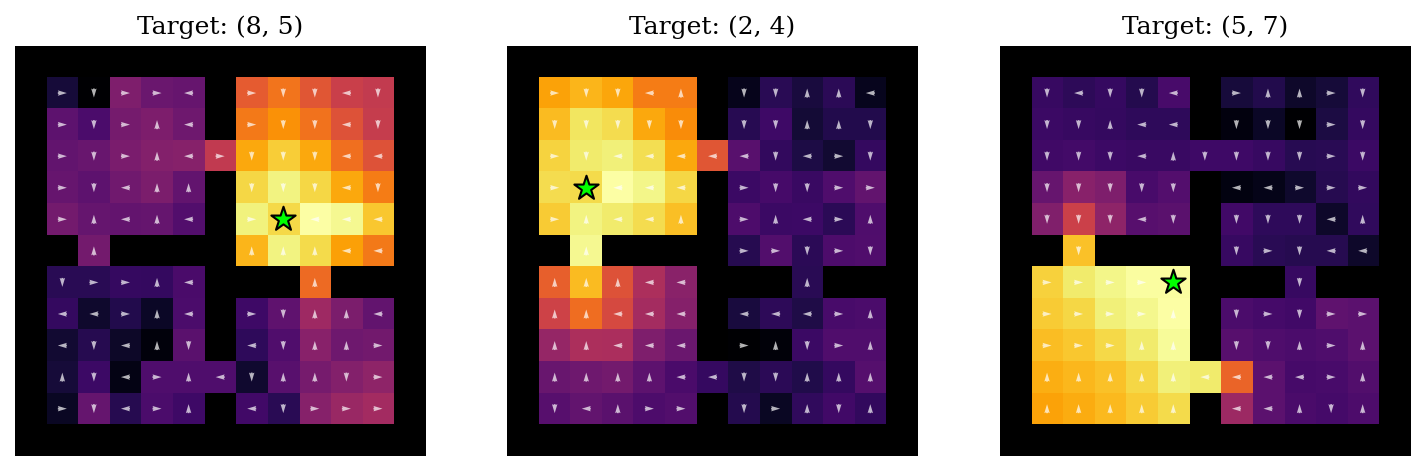


--- Visualization at Update 16000 ---


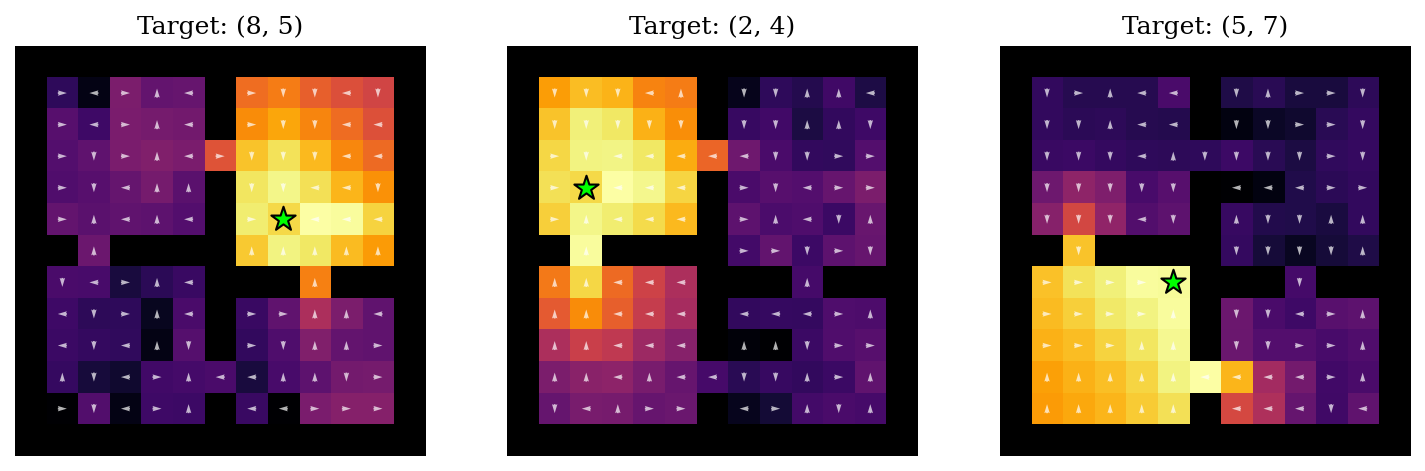


--- Visualization at Update 18000 ---


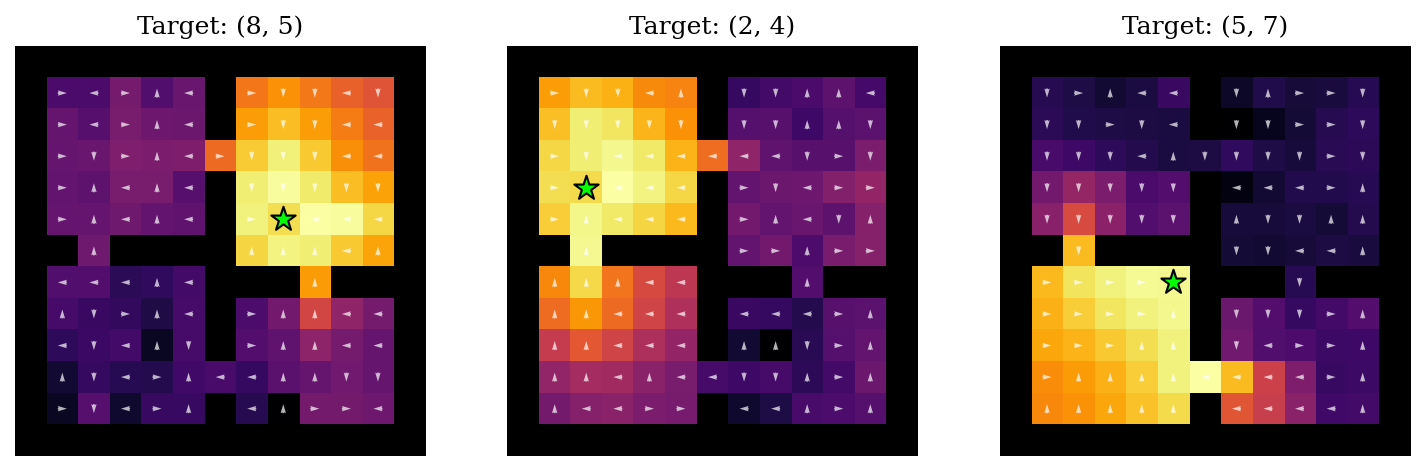


--- Visualization at Update 20000 ---


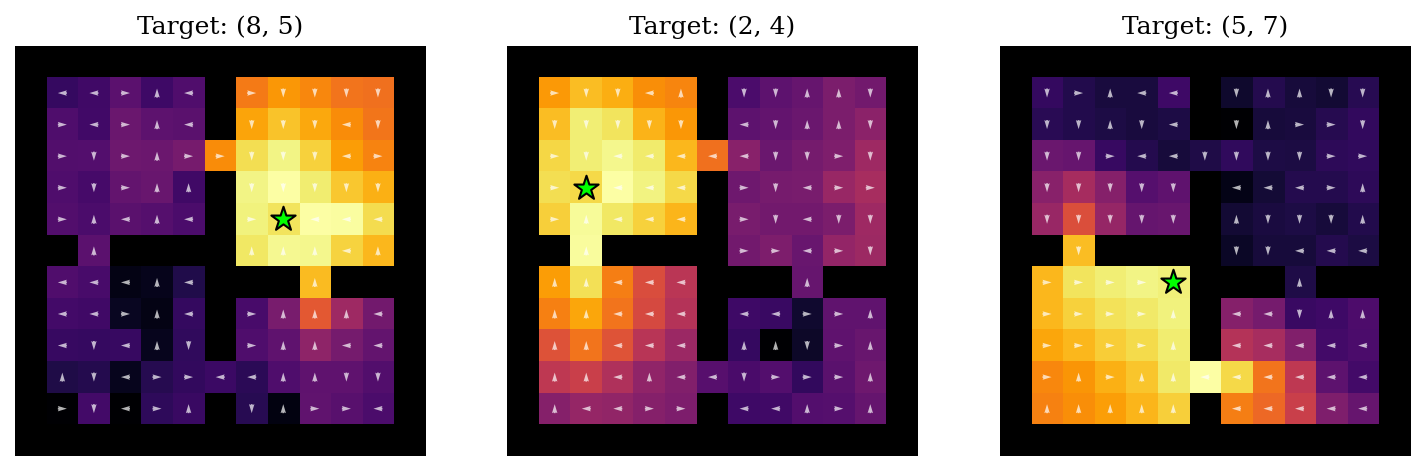


--- Visualization at Update 22000 ---


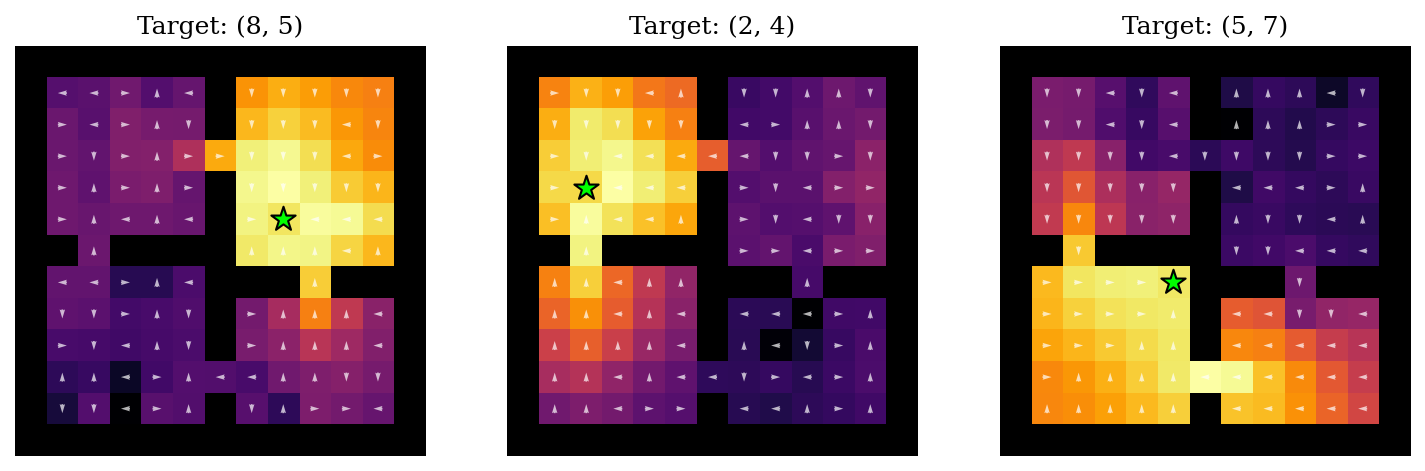


--- Visualization at Update 24000 ---


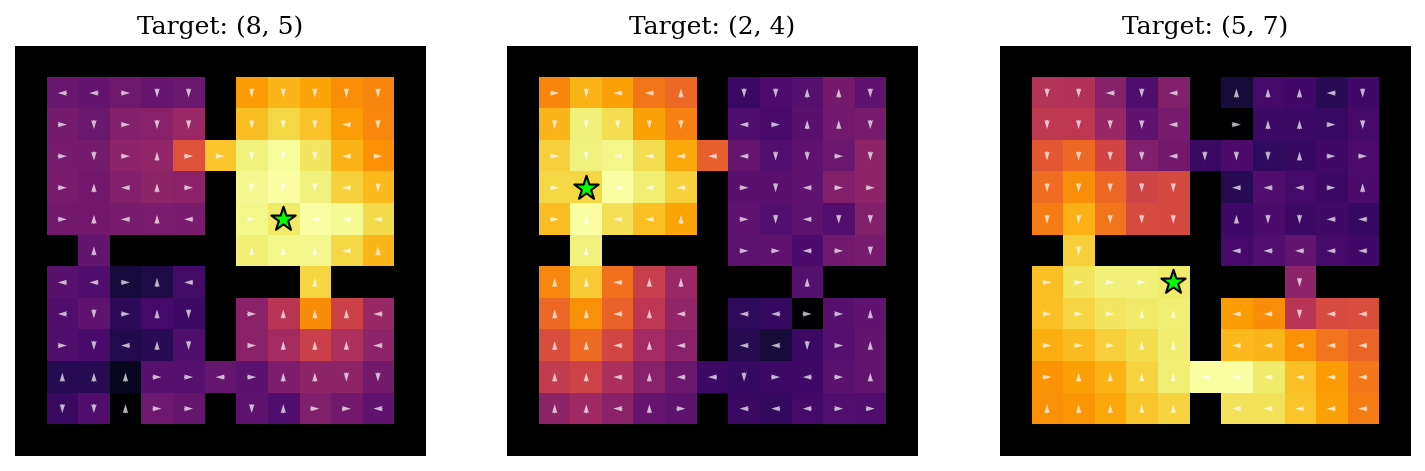


--- Visualization at Update 26000 ---


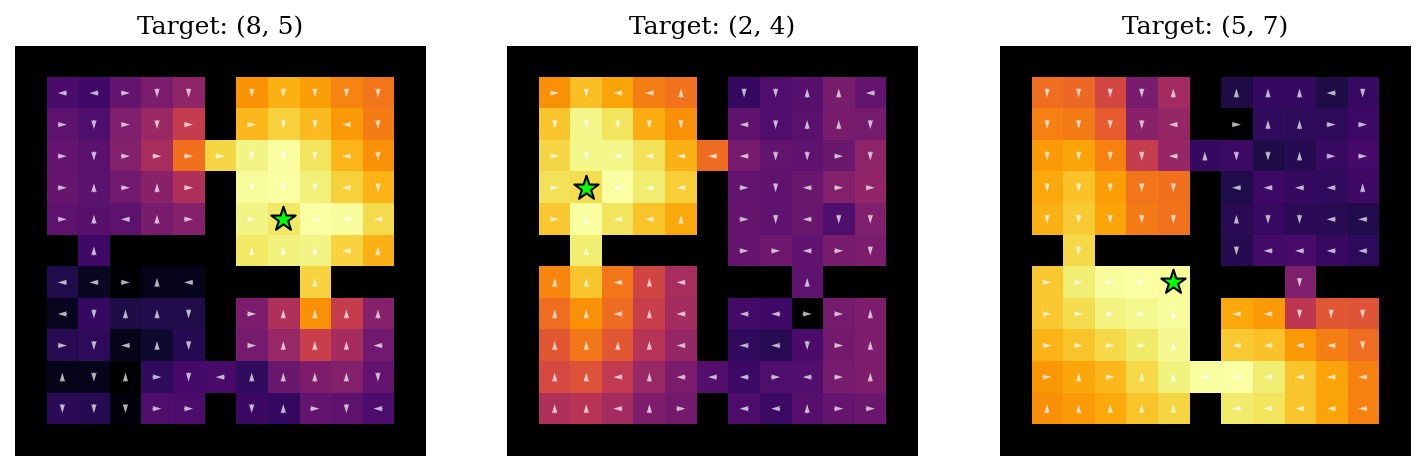


--- Visualization at Update 28000 ---


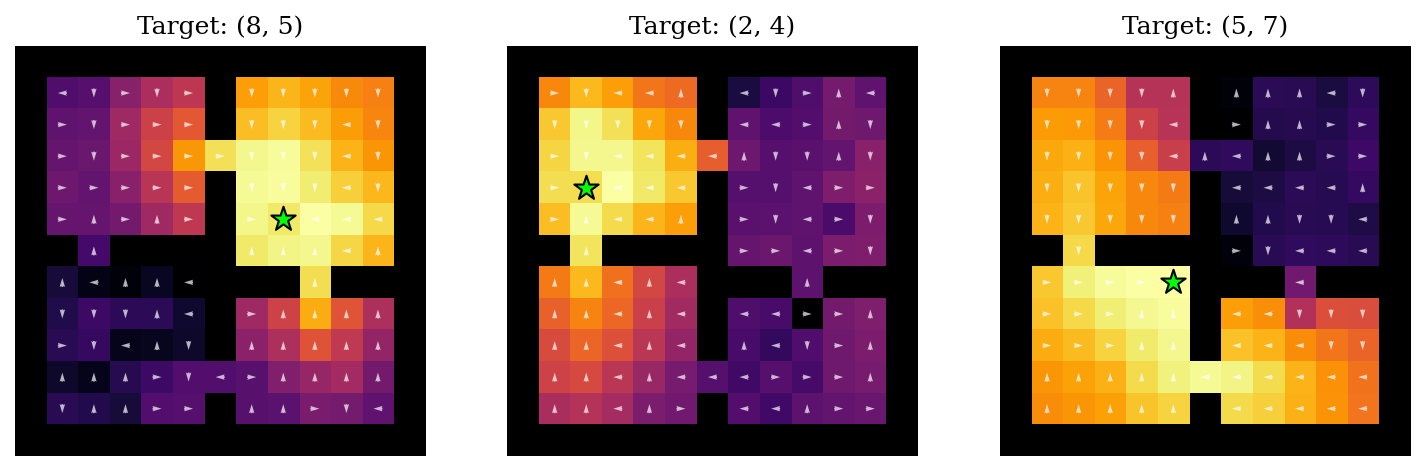


--- Visualization at Update 30000 ---


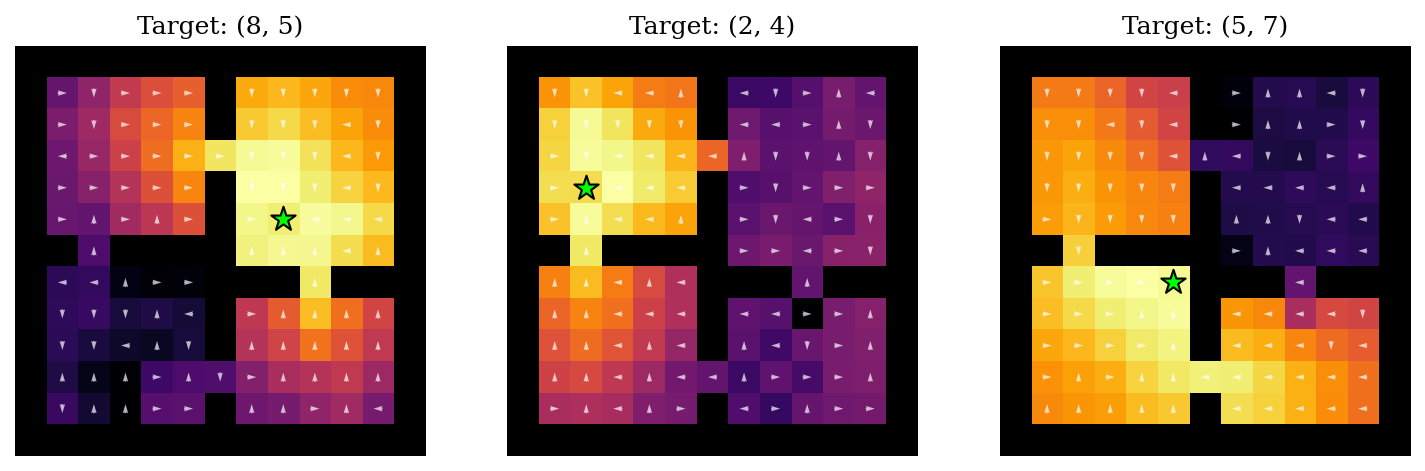


--- Visualization at Update 32000 ---


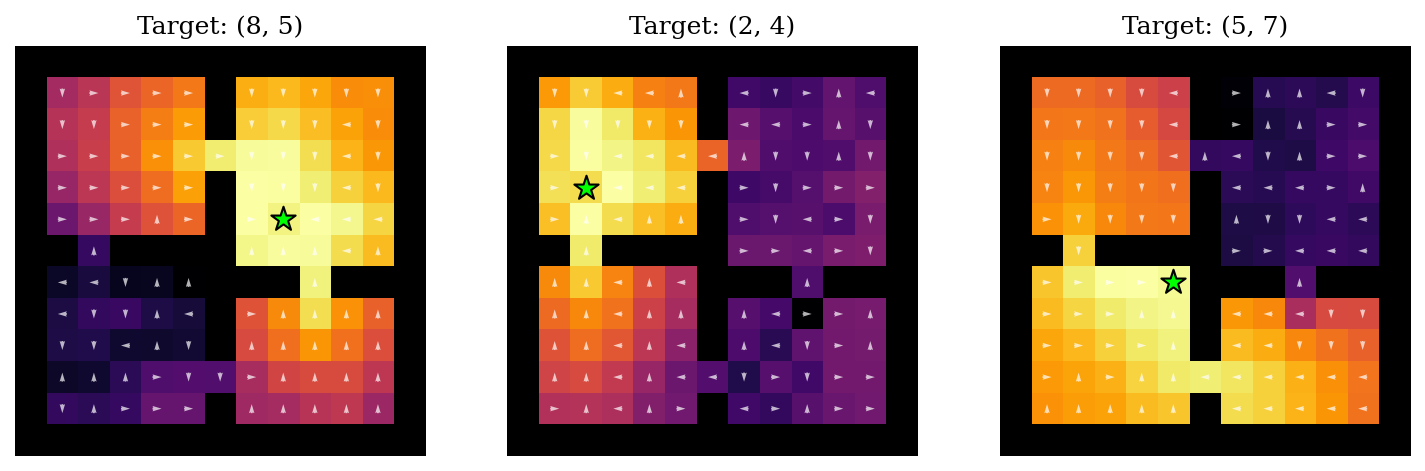


--- Visualization at Update 34000 ---


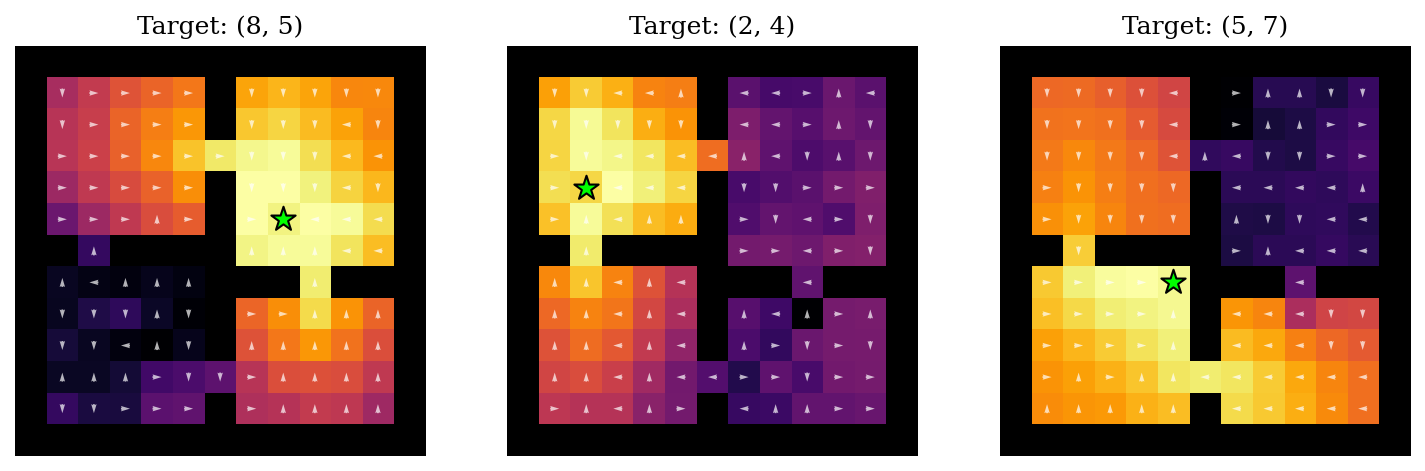


--- Visualization at Update 36000 ---


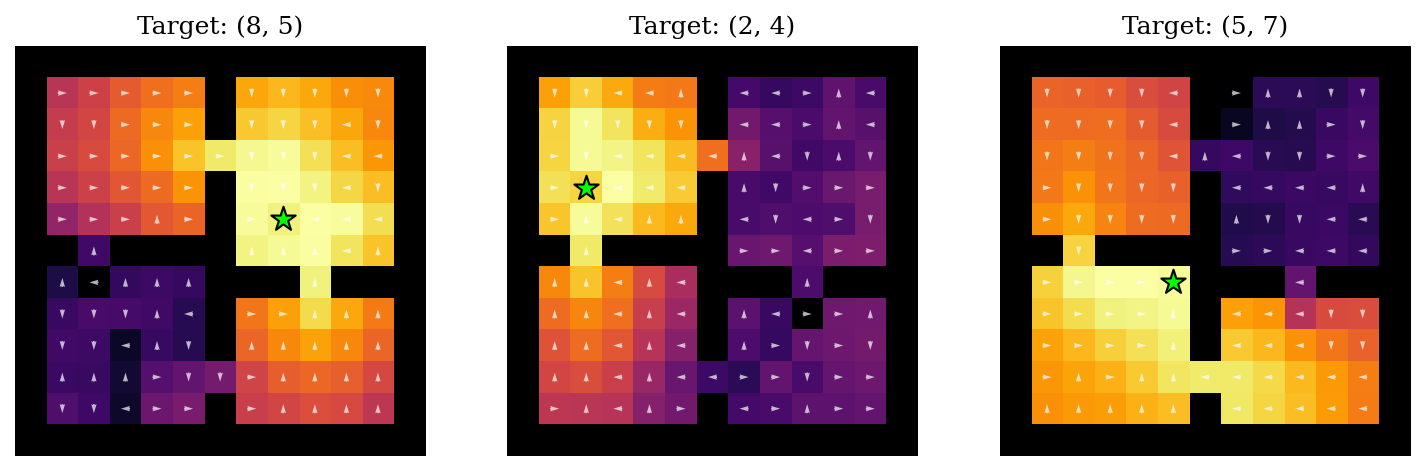


--- Visualization at Update 38000 ---


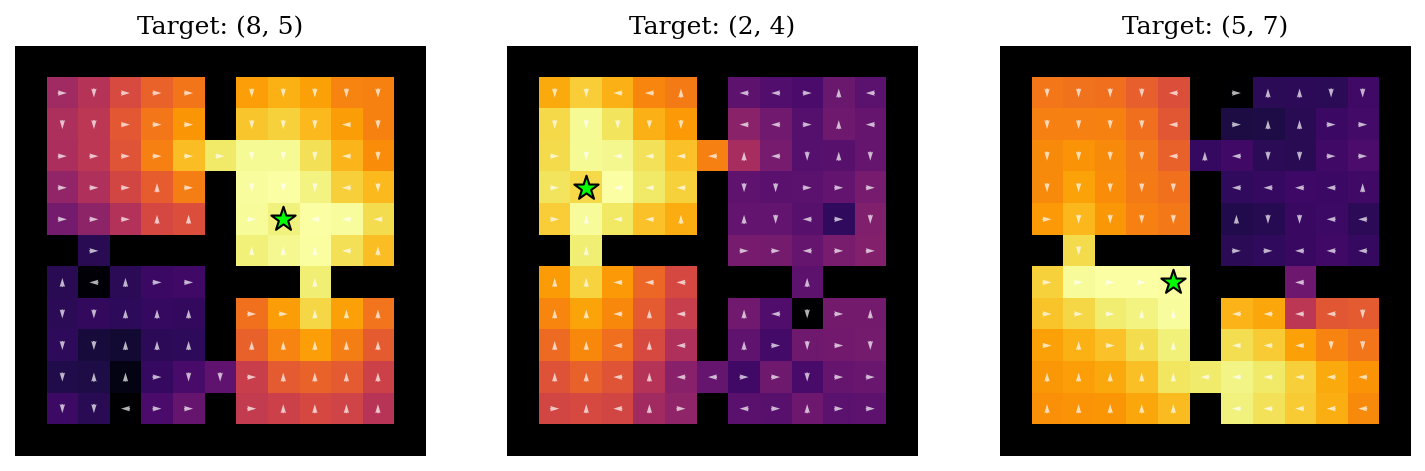


--- Visualization at Update 40000 ---


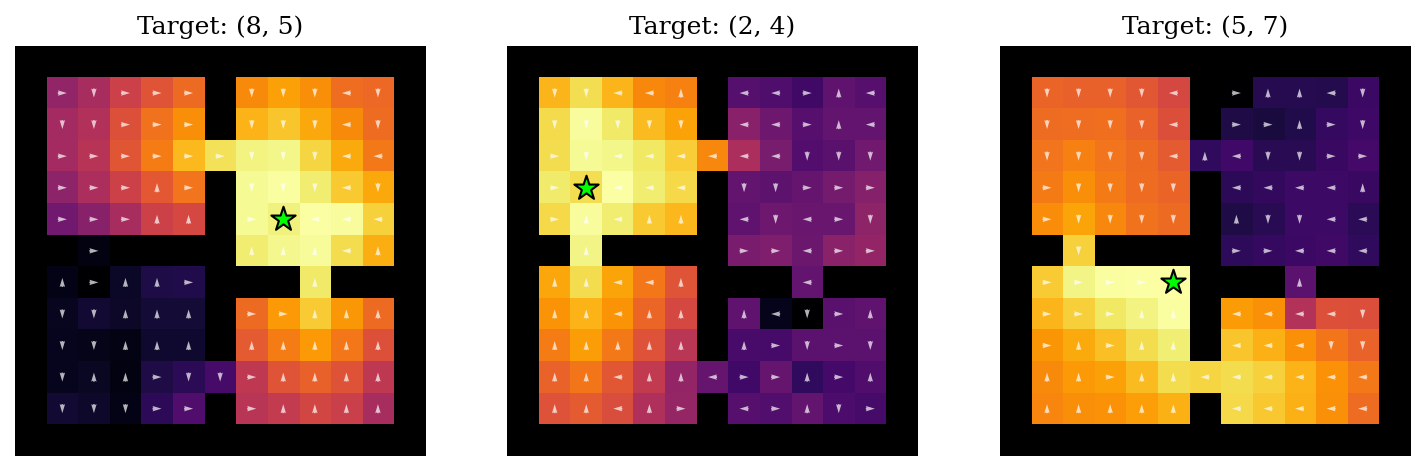


--- Visualization at Update 42000 ---


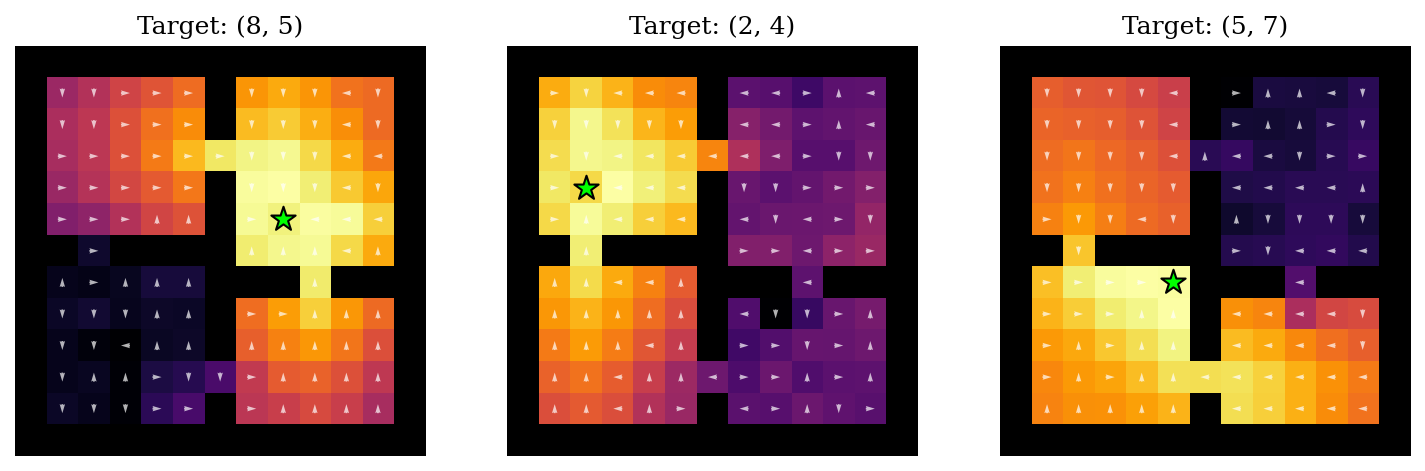


--- Visualization at Update 44000 ---


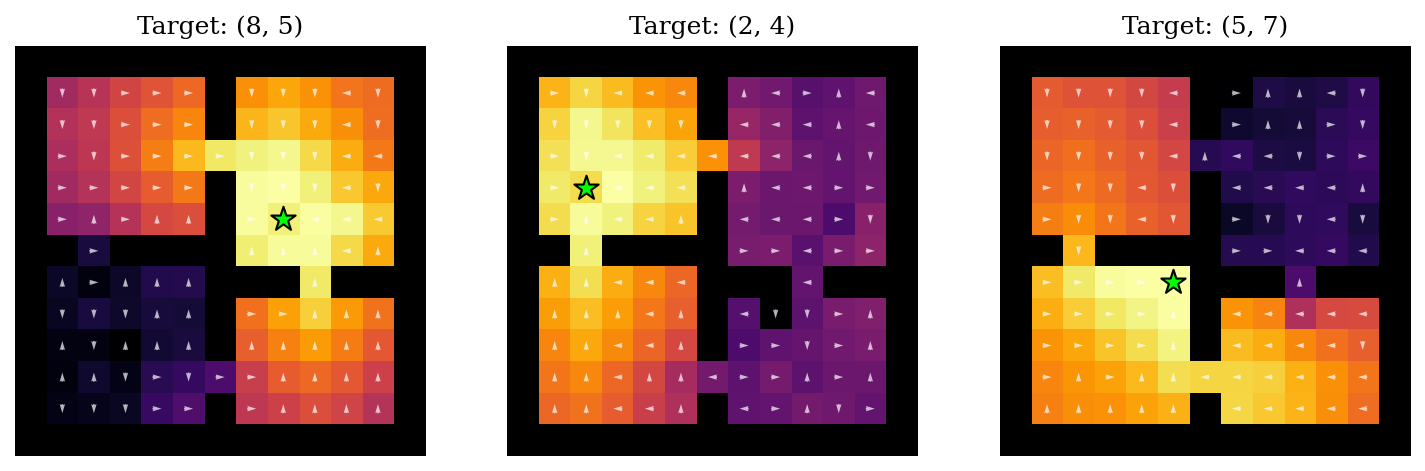


--- Visualization at Update 46000 ---


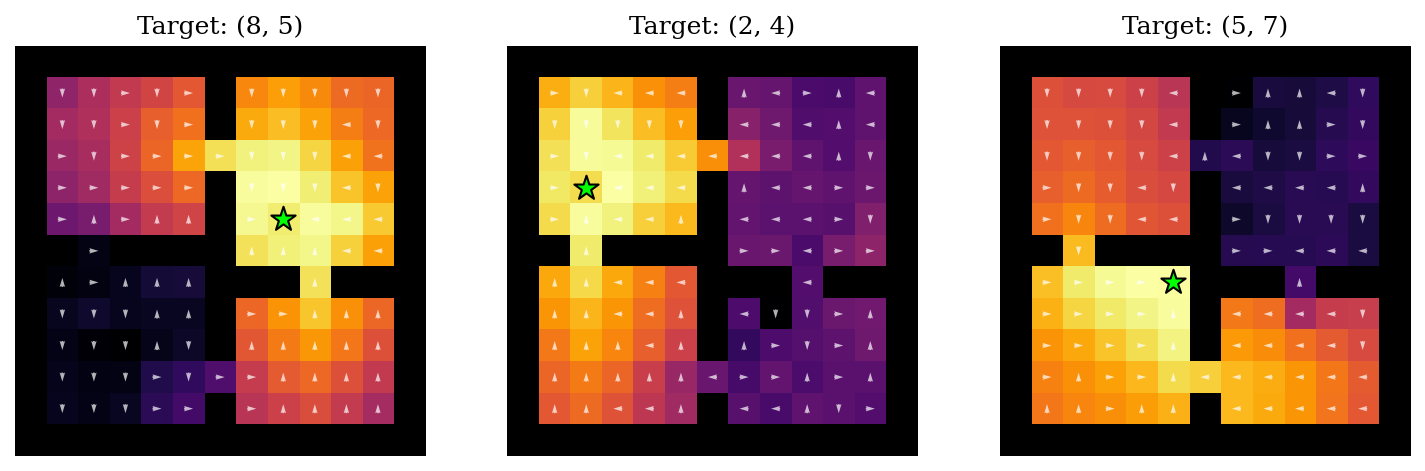


--- Visualization at Update 48000 ---


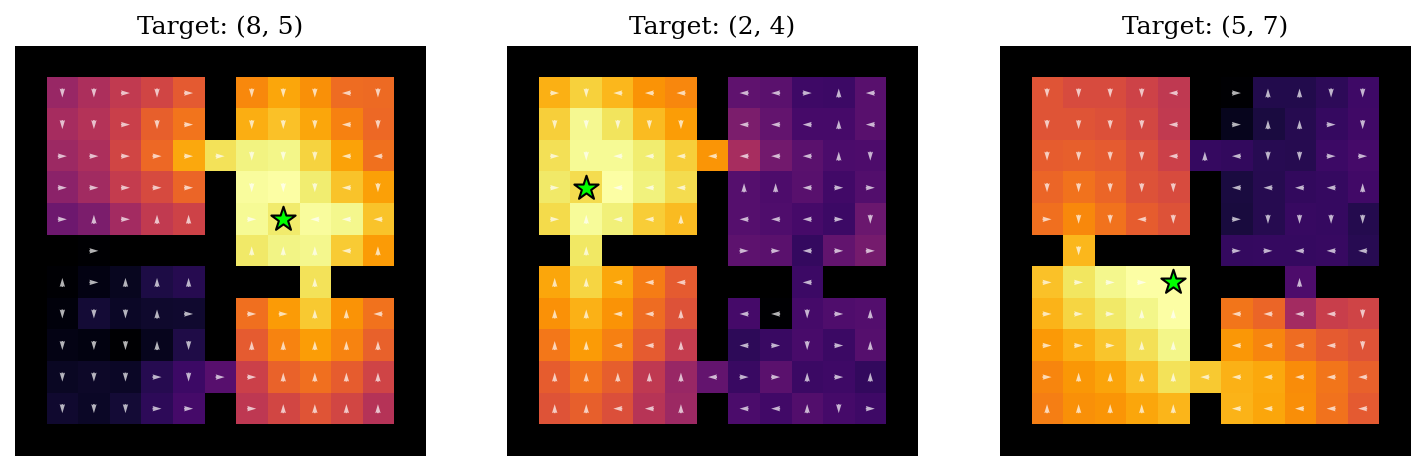


--- Visualization at Update 50000 ---


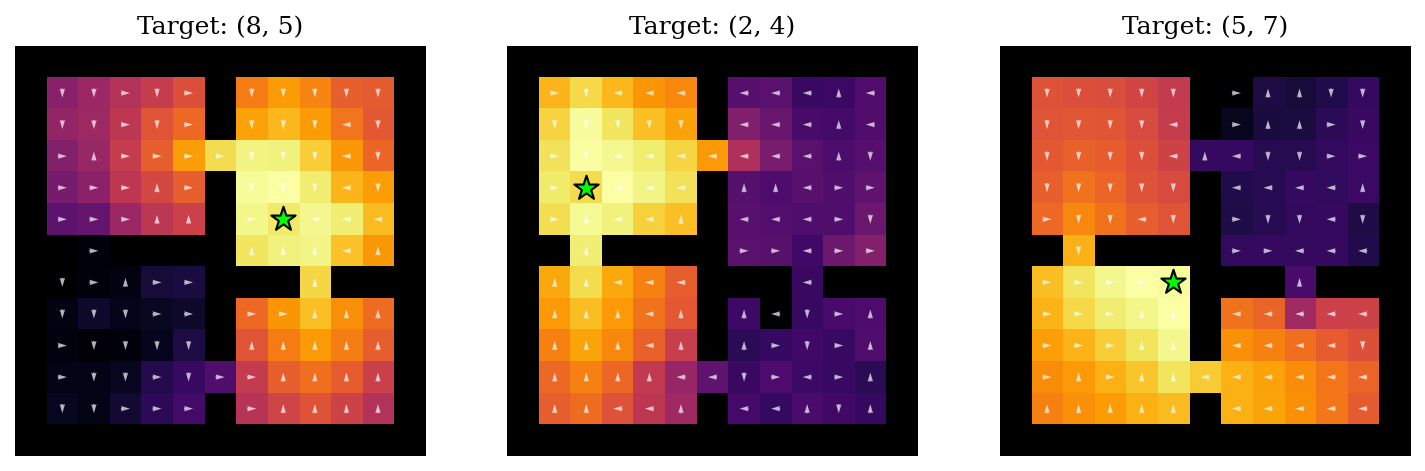


--- Visualization at Update 52000 ---


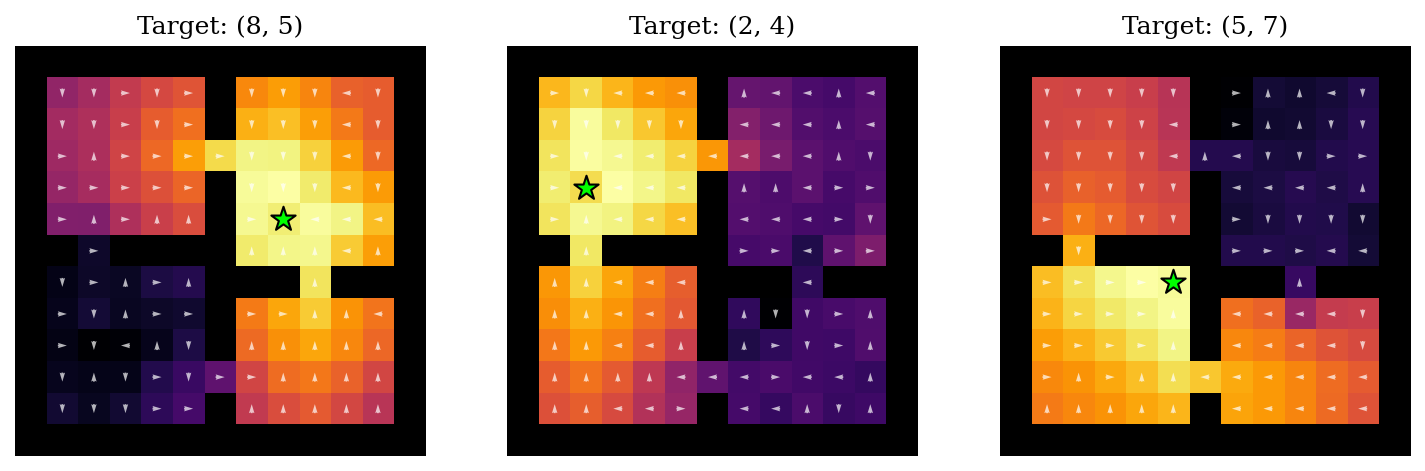


--- Visualization at Update 54000 ---


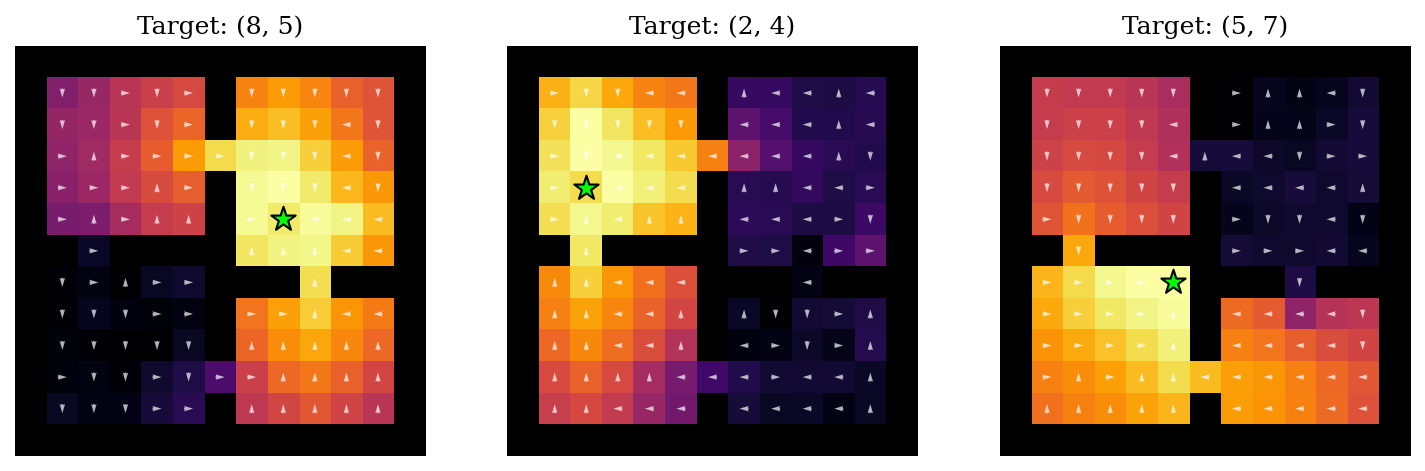


--- Visualization at Update 56000 ---


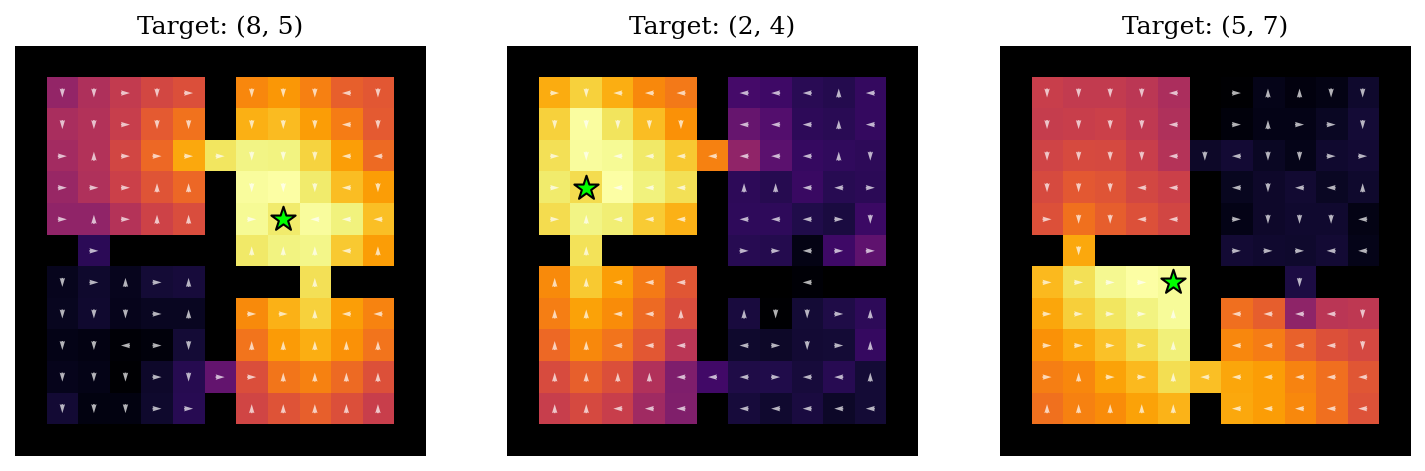


--- Visualization at Update 58000 ---


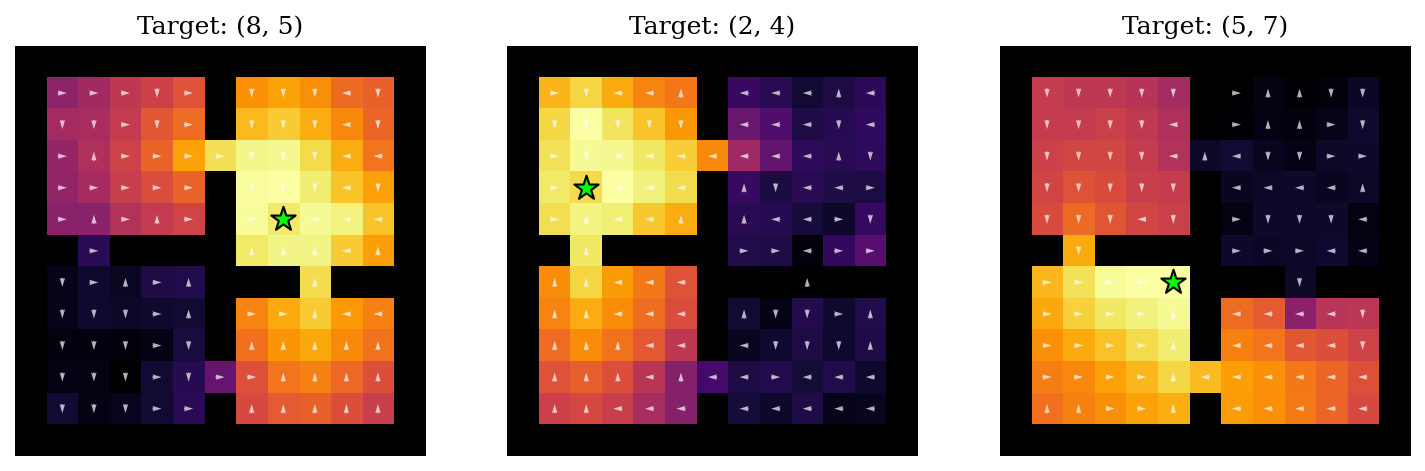


--- Visualization at Update 60000 ---


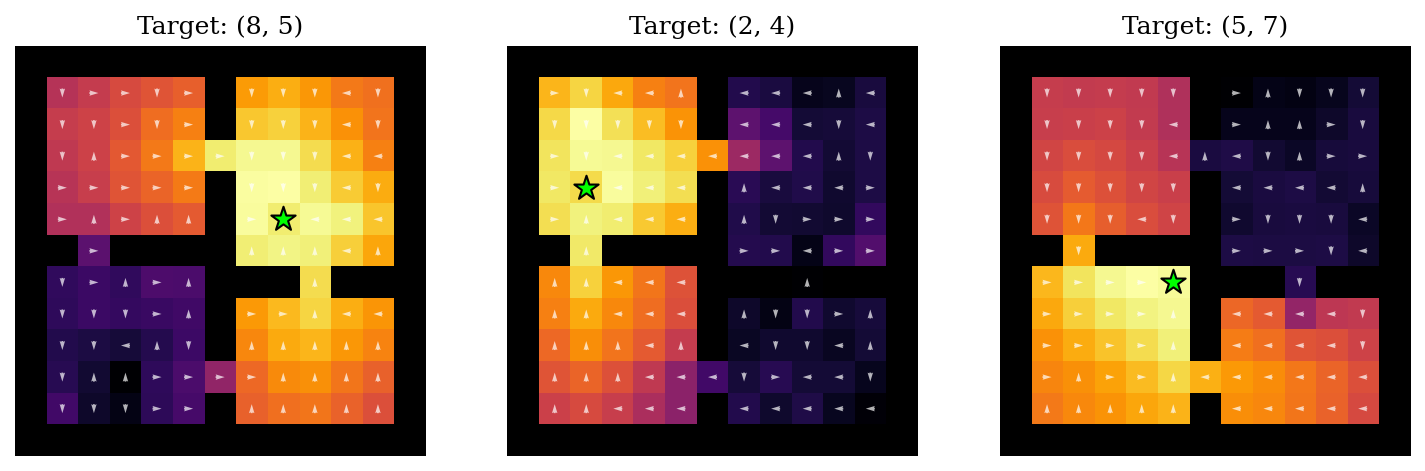


--- Visualization at Update 62000 ---


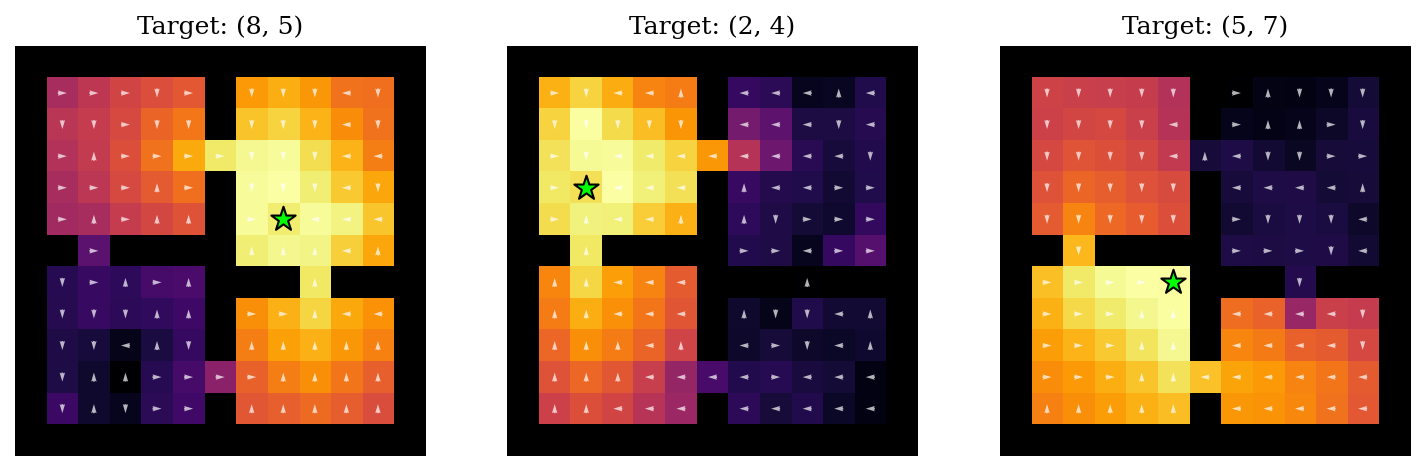


--- Visualization at Update 64000 ---


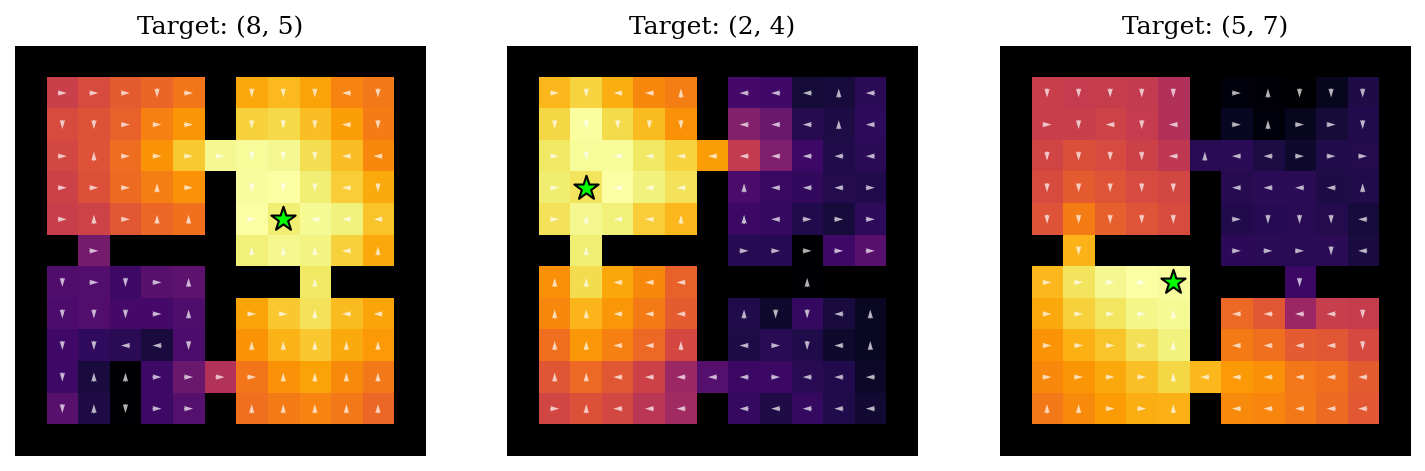


--- Visualization at Update 66000 ---


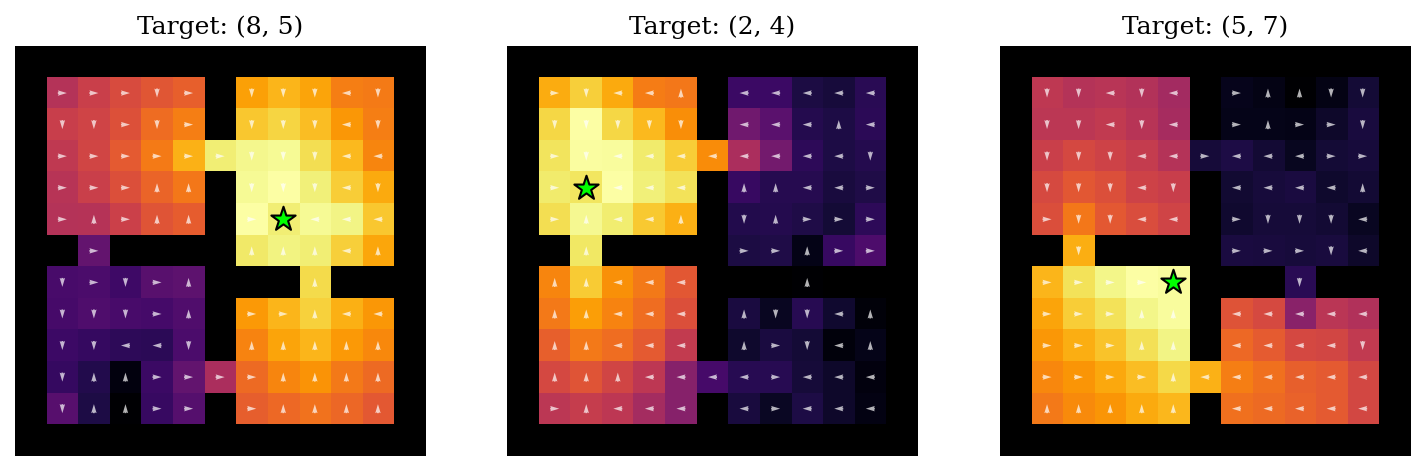


--- Visualization at Update 68000 ---


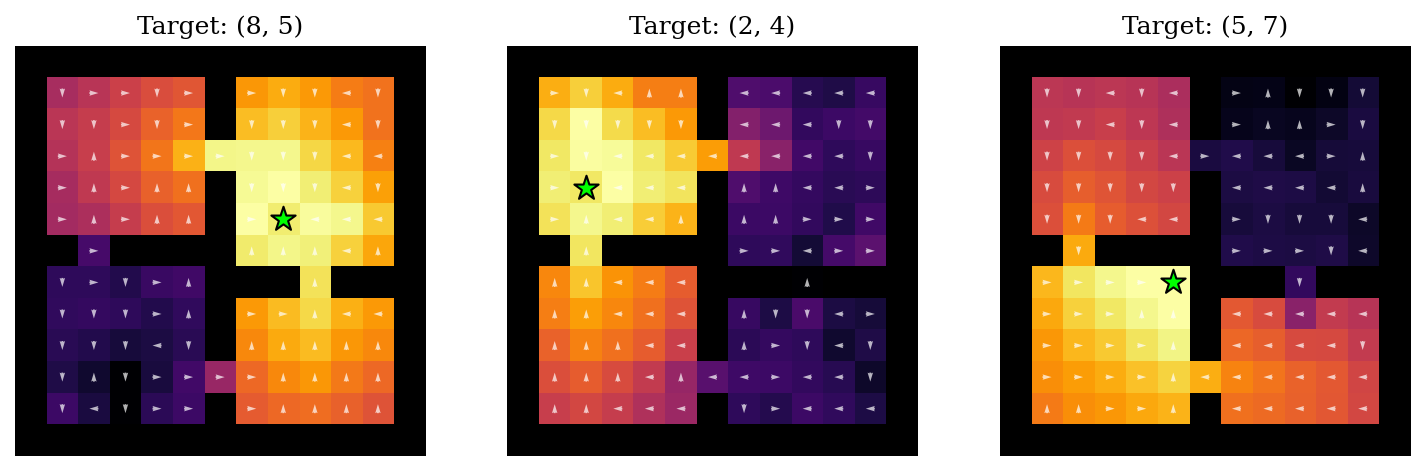


--- Visualization at Update 70000 ---


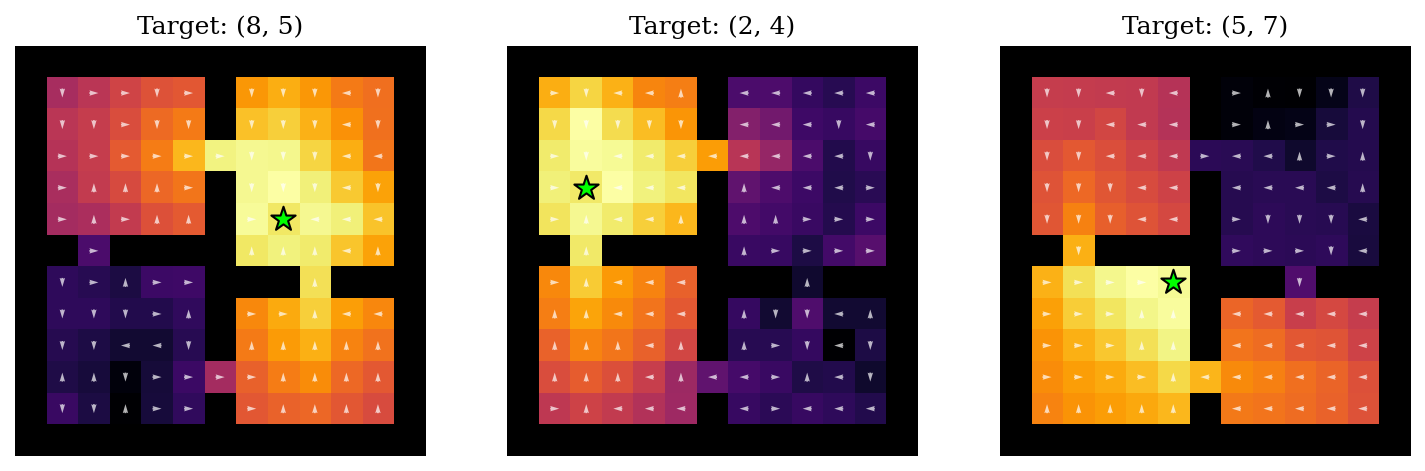


--- Visualization at Update 72000 ---


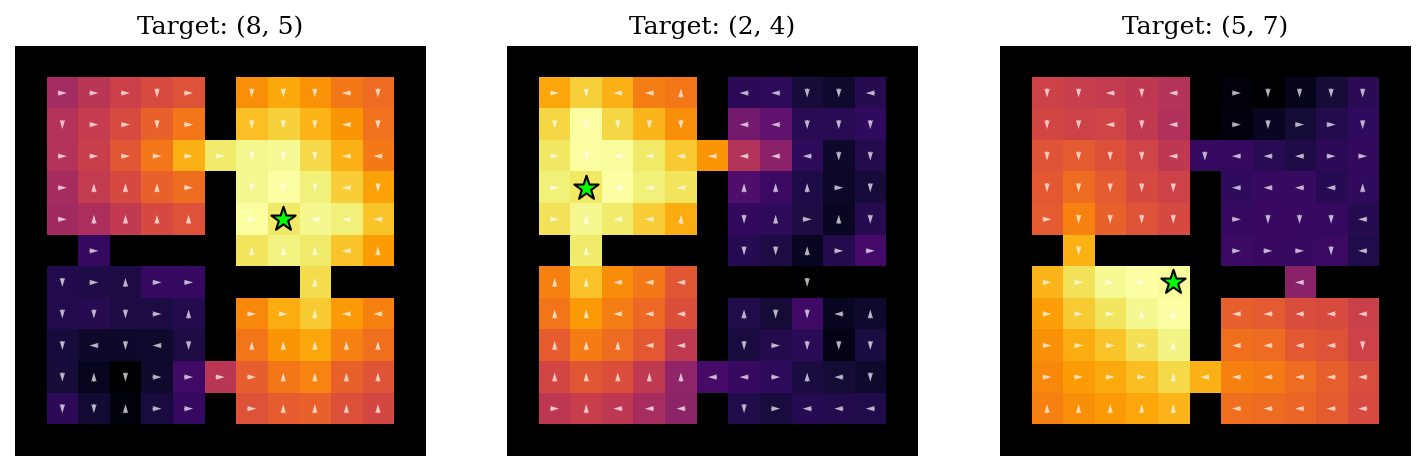


--- Visualization at Update 74000 ---


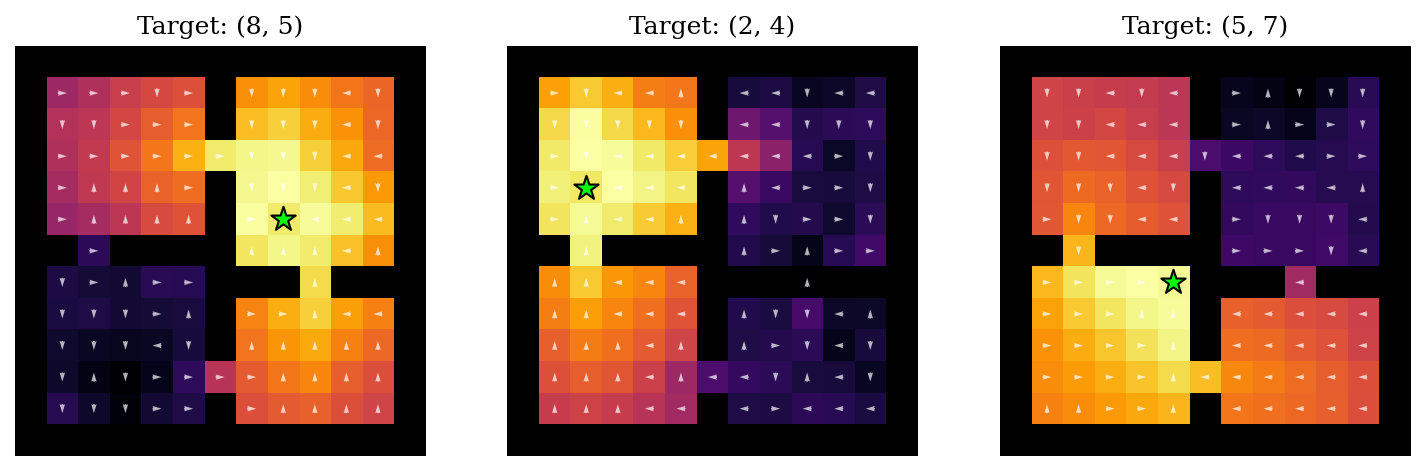


--- Visualization at Update 76000 ---


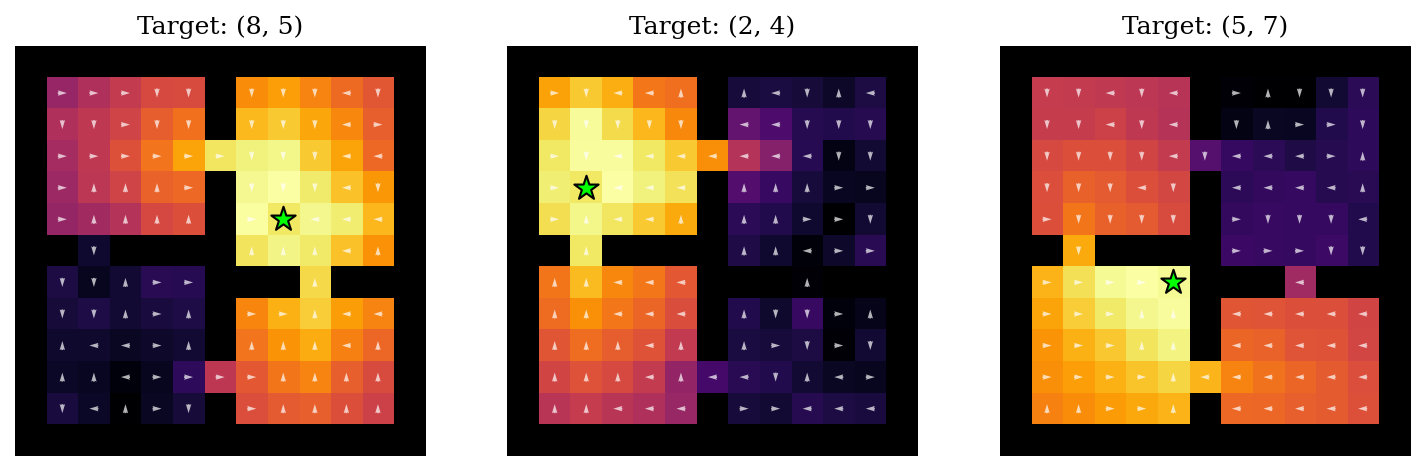


--- Visualization at Update 78000 ---


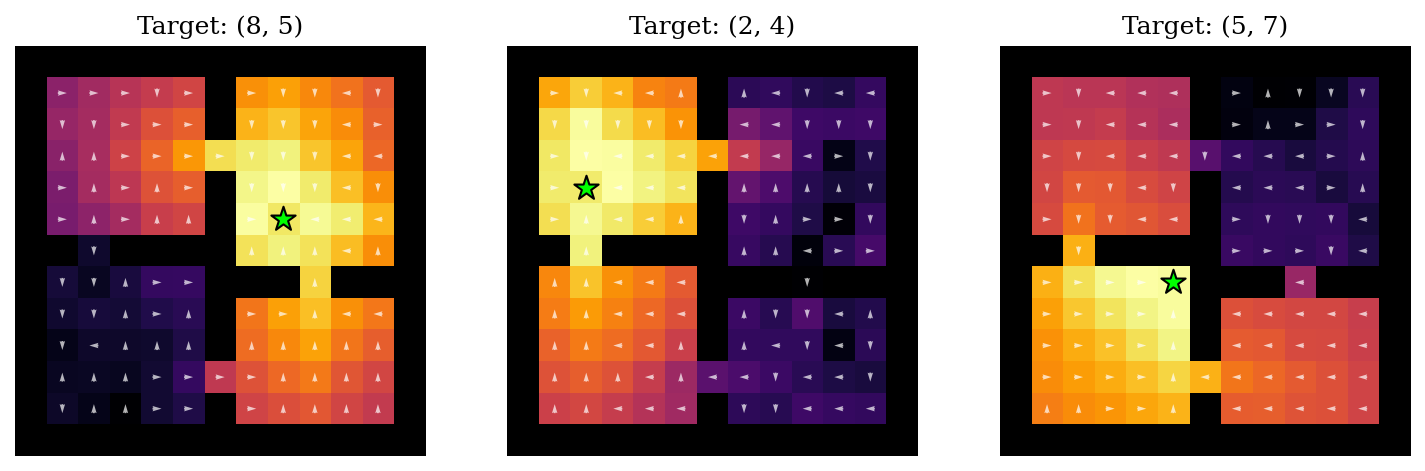


--- Visualization at Update 80000 ---


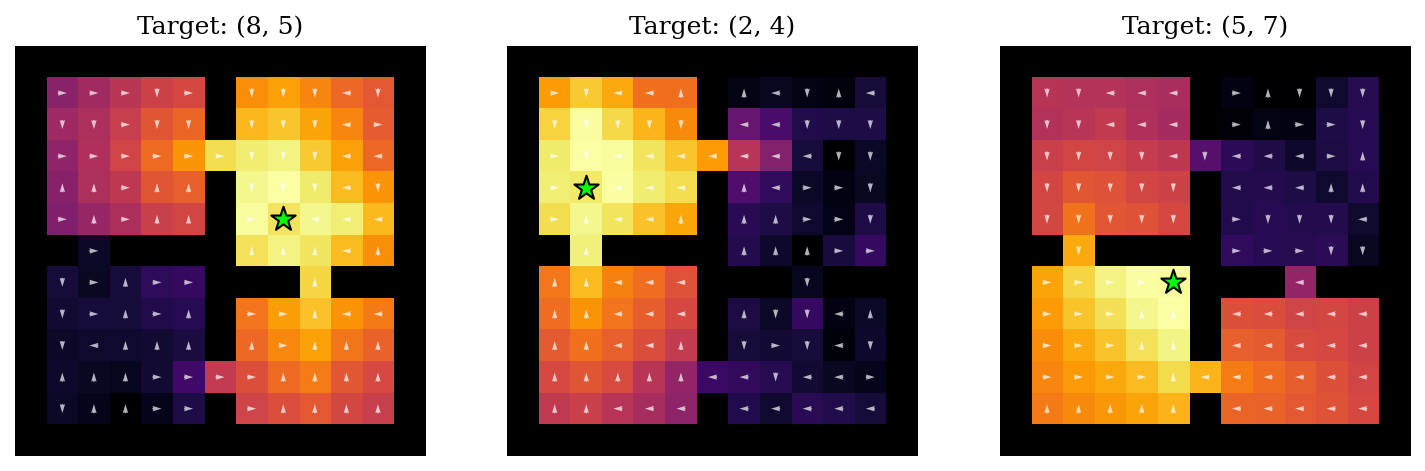


--- Visualization at Update 82000 ---


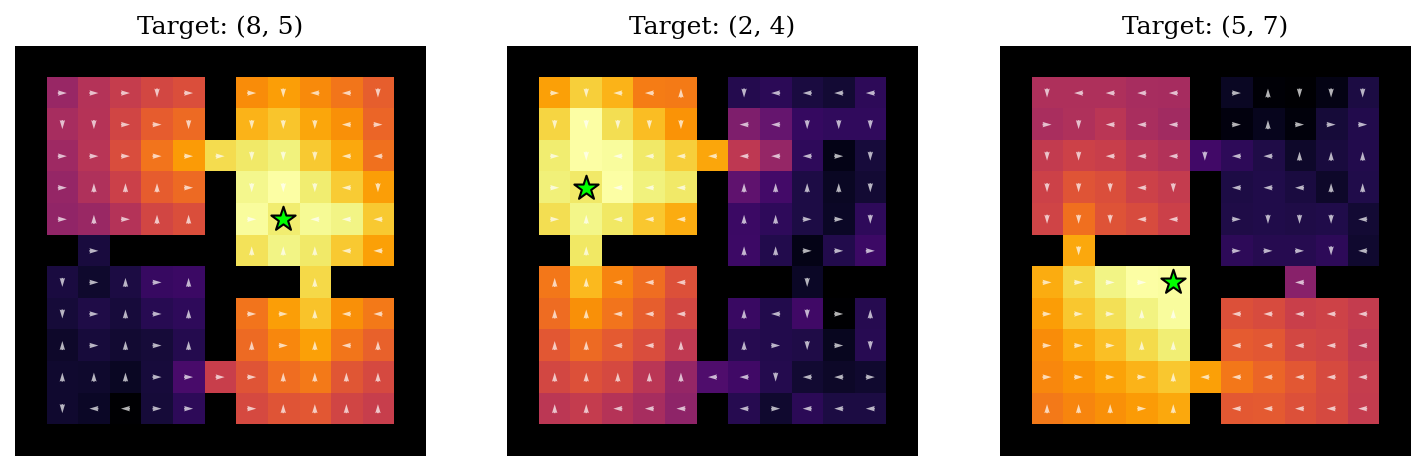


--- Visualization at Update 84000 ---


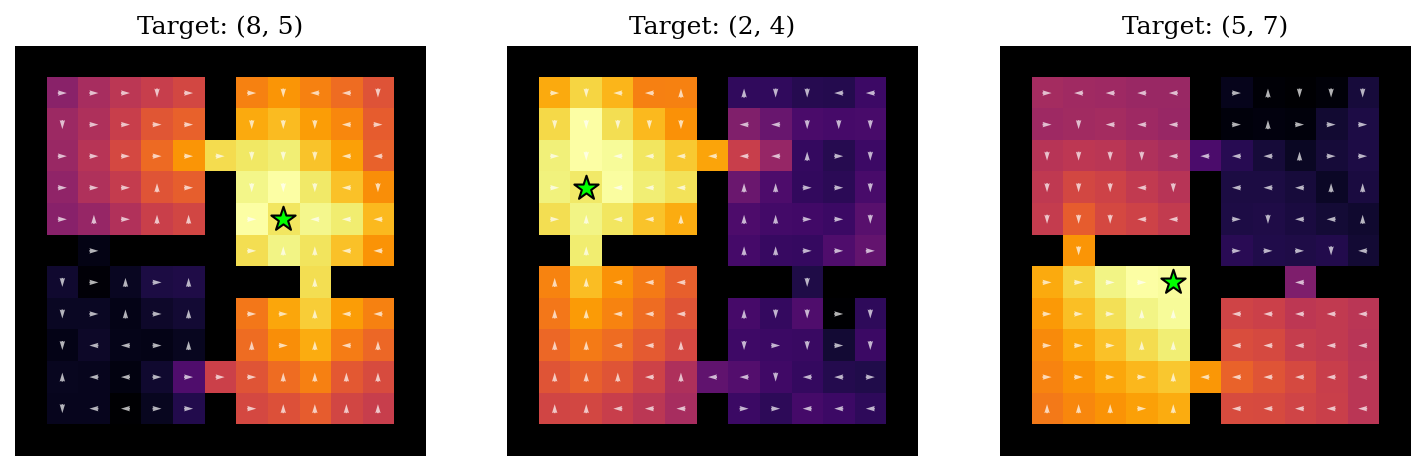


--- Visualization at Update 86000 ---


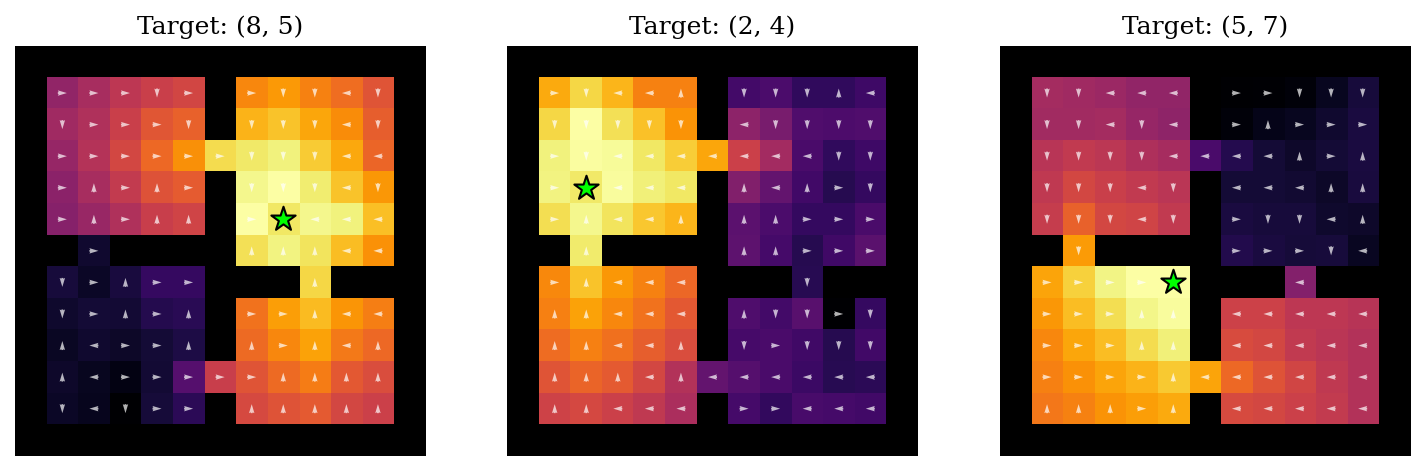


--- Visualization at Update 88000 ---


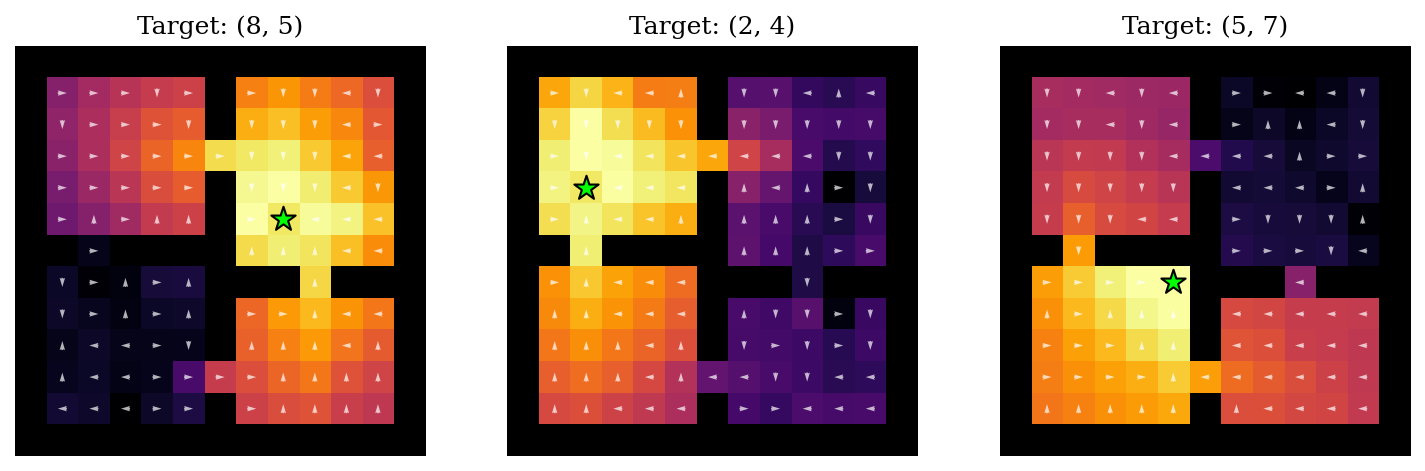


--- Visualization at Update 90000 ---


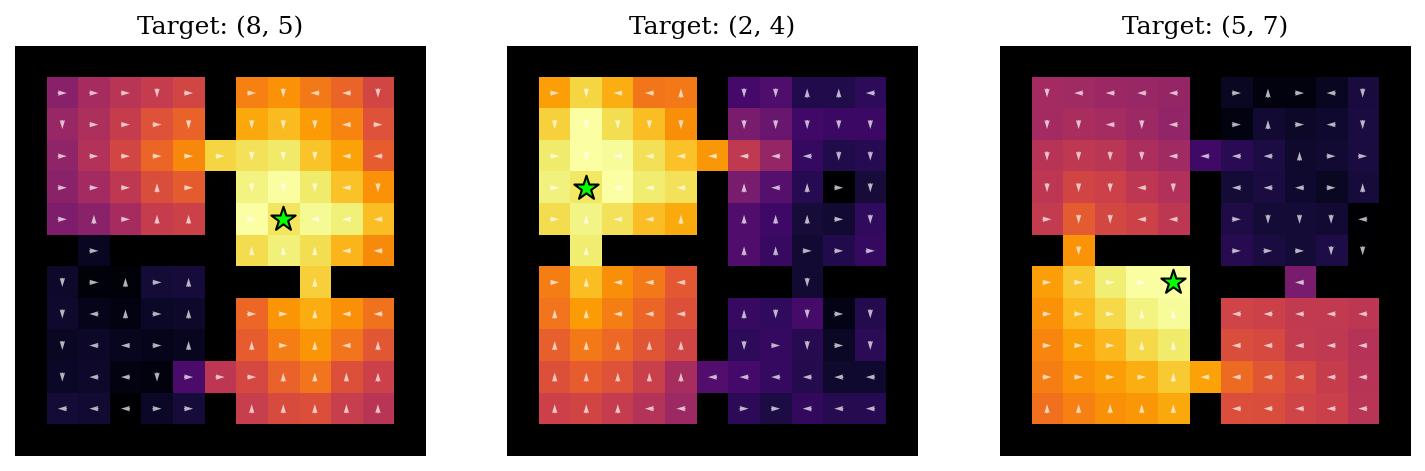


--- Visualization at Update 92000 ---


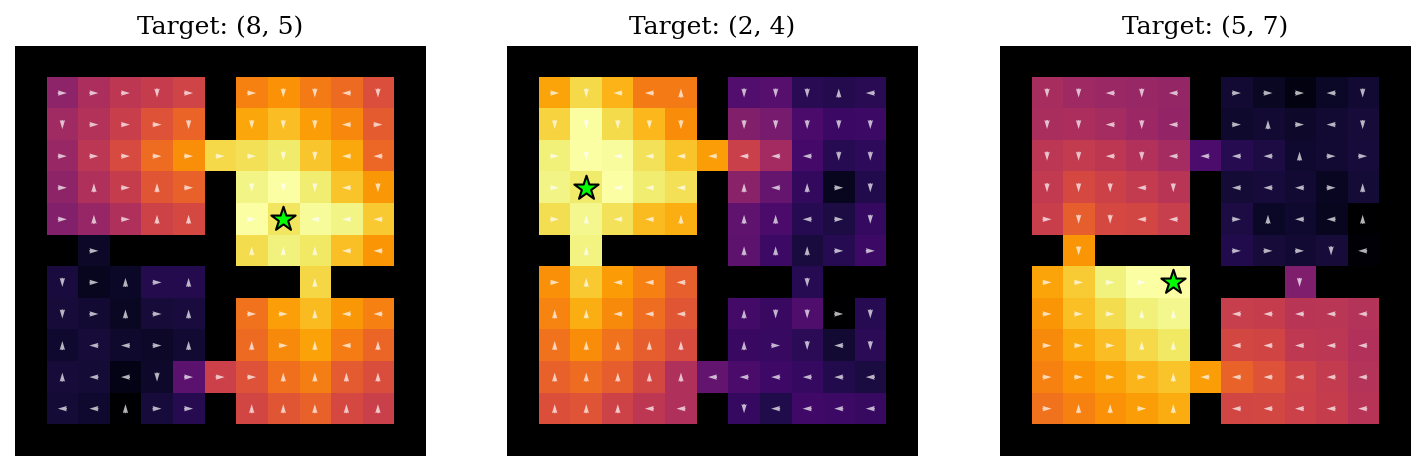


--- Visualization at Update 94000 ---


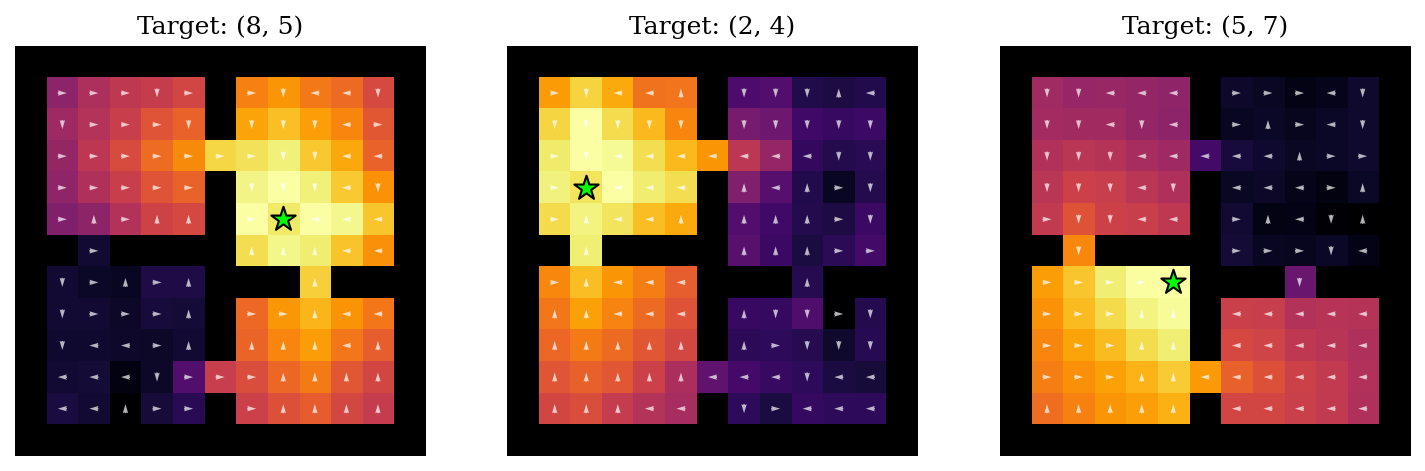


--- Visualization at Update 96000 ---


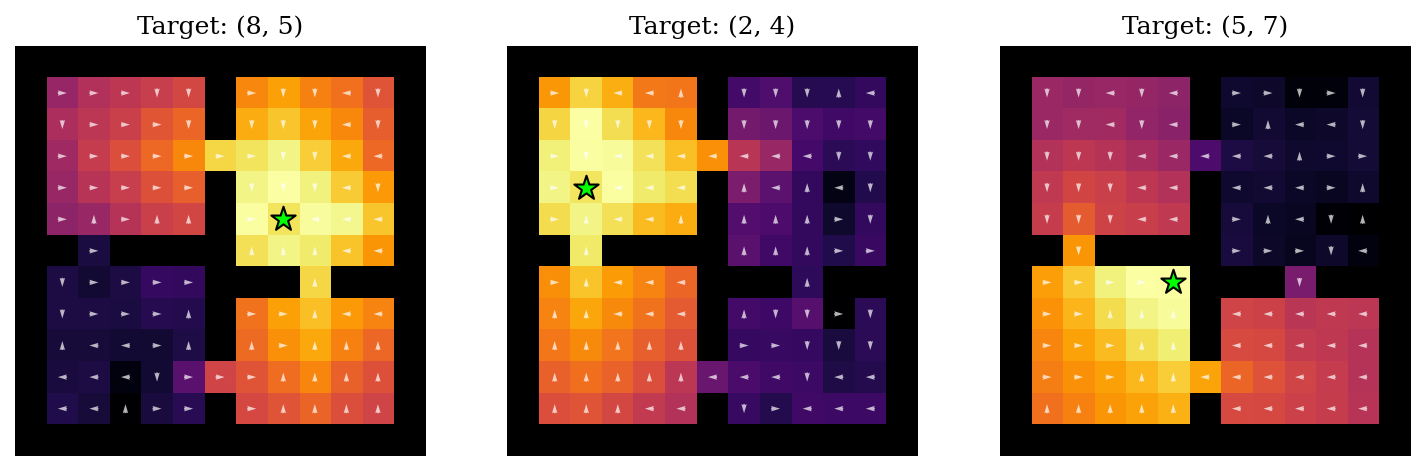

KeyboardInterrupt: 

In [60]:
viz_goals = [(8, 5), (2, 4), (5, 7)] 

num_updates = 100_000
print(f"\nStarting FB training for {num_updates} iterations...")

pbar = tqdm(range(num_updates + 1))
for i in pbar:
    metrics = agent.update(replay_buffer, i)
    
    if i % 1000 == 0:
        pbar.set_postfix({'fb_loss': metrics['fb_loss'].item(),
                        'fb_diag': metrics['fb_diag'].item(),
                        'fb_offdiag': metrics['fb_offdiag'].item()})
    
    if i > 0 and i % 2000 == 0:
        print(f"\n--- Visualization at Update {i} ---")
        visualize_fb(env, agent, viz_goals)